# Problem Statement

#### Thera Bank saw sharp declines in its credit card users. The objective of this notebook is to create a classificatiom model that will help the bank improve its services and retain customers. This notebook explores the dataset, builds a classification model, optimizes the model using pipeline and hyperparameter tuning, and provides insights on how the bank can improve its business model

# Libraries and Understanding Data

In [79]:
#Import necessary libraries:
import scipy.stats as stats 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
import statsmodels.api as sm
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn import metrics
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
    StackingClassifier)

from xgboost import XGBClassifier
from sklearn import tree
from sklearn.linear_model import LogisticRegression

#Missing Value Imputations
from sklearn.impute import KNNImputer
#Model Tuning

from sklearn.metrics import  classification_report, accuracy_score, precision_score, recall_score,f1_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,plot_confusion_matrix #to plot confusion matric

from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

#Ignore warnings
warnings.filterwarnings("ignore")

In [83]:
#Reads the csv file to create a dataframe
df = pd.read_csv("BankChurners.csv")

In [84]:
#Reads the csv file to create a dataframe
df.head()

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


In [85]:
#Gives the total number of rows and columns
df.shape

(10127, 21)

In [86]:
#Gives the name of the columns in the dataframe
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio'],
      dtype='object')

In [87]:
#Checking for missing values
df.isnull().sum().sort_values(ascending=False)

Education_Level             1519
Marital_Status               749
CLIENTNUM                      0
Contacts_Count_12_mon          0
Total_Ct_Chng_Q4_Q1            0
Total_Trans_Ct                 0
Total_Trans_Amt                0
Total_Amt_Chng_Q4_Q1           0
Avg_Open_To_Buy                0
Total_Revolving_Bal            0
Credit_Limit                   0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Attrition_Flag                 0
Months_on_book                 0
Card_Category                  0
Income_Category                0
Dependent_count                0
Gender                         0
Customer_Age                   0
Avg_Utilization_Ratio          0
dtype: int64

In [88]:
#Gives total number of entries and data types of each column.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

In [89]:
#Gives basic statistics of the dataset, including quartiles, mean, minimum, maximum, etc. 
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.0,7.391776e+08,3.690378e+07,708082083.0,7.130368e+08,7.179264e+08,7.731435e+08,8.283431e+08
Customer_Age,10127.0,4.632596e+01,8.016814e+00,26.0,4.100000e+01,4.600000e+01,5.200000e+01,7.300000e+01
Dependent_count,10127.0,2.346203e+00,1.298908e+00,0.0,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
Months_on_book,10127.0,3.592841e+01,7.986416e+00,13.0,3.100000e+01,3.600000e+01,4.000000e+01,5.600000e+01
Total_Relationship_Count,10127.0,3.812580e+00,1.554408e+00,1.0,3.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Months_Inactive_12_mon,10127.0,2.341167e+00,1.010622e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Contacts_Count_12_mon,10127.0,2.455317e+00,1.106225e+00,0.0,2.000000e+00,2.000000e+00,3.000000e+00,6.000000e+00
Credit_Limit,10127.0,8.631954e+03,9.088777e+03,1438.3,2.555000e+03,4.549000e+03,1.106750e+04,3.451600e+04
Total_Revolving_Bal,10127.0,1.162814e+03,8.149873e+02,0.0,3.590000e+02,1.276000e+03,1.784000e+03,2.517000e+03
Avg_Open_To_Buy,10127.0,7.469140e+03,9.090685e+03,3.0,1.324500e+03,3.474000e+03,9.859000e+03,3.451600e+04


# Data Preprocessing

In [90]:
#CLIENTNUM is not a needed column, so let's drop it
df.drop(["CLIENTNUM"],axis=1,inplace=True)

In [91]:
cat_cols = ["Attrition_Flag","Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category","Dependent_count","Total_Relationship_Count","Months_Inactive_12_mon","Contacts_Count_12_mon"]

In [92]:
#Loop to print out counts for each column
for col in cat_cols:
    print(f"Feature: {col}")
    print("-"*40)
    display(pd.DataFrame({"Counts": df[col].value_counts(dropna=False)}).sort_values(by="Counts", ascending=False))

Feature: Attrition_Flag
----------------------------------------


,Counts
Existing Customer,8500
Attrited Customer,1627


Feature: Gender
----------------------------------------


,Counts
F,5358
M,4769


Feature: Education_Level
----------------------------------------


...

,Counts
3,2305
4,1912
5,1891
6,1866
2,1243
1,910


Feature: Months_Inactive_12_mon
----------------------------------------


,Counts
3,3846
2,3282
1,2233
4,435
5,178
6,124
0,29


Feature: Contacts_Count_12_mon
----------------------------------------


,Counts
3,3380
2,3227
1,1499
4,1392
0,399
5,176
6,54


### 1627 customers closed their accounts
### 1519 customers are in the NaN category for Education Level. That must be addressed in the missing values treatment.
### 749 customers are in the NaN category for Marital Status. That must be addressed in the missing values treatment.
### 1112 customers are in the abc category for Income Category. That must be addressed in the missing values treatment.
### Most customers have blue cards while platinum cards have the least

In [93]:
#Convert data types to category
cat_cols = ["Attrition_Flag","Gender", "Education_Level", "Marital_Status", "Income_Category", "Card_Category","Dependent_count","Total_Relationship_Count","Months_Inactive_12_mon","Contacts_Count_12_mon"]

df[cat_cols] = df[cat_cols].astype("category")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  category
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  category
 4   Education_Level           8608 non-null   category
 5   Marital_Status            9378 non-null   category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  category
 10  Months_Inactive_12_mon    10127 non-null  category
 11  Contacts_Count_12_mon     10127 non-null  category
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

In [94]:
df.describe(include=["category"]).T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Dependent_count,10127,6,3,2732
Education_Level,8608,6,Graduate,3128
Marital_Status,9378,3,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436
Total_Relationship_Count,10127,6,3,2305
Months_Inactive_12_mon,10127,7,3,3846
Contacts_Count_12_mon,10127,7,3,3380


In [95]:
#Find number of unique values in each column
for i in cat_cols:
    print("Unique values in",i, ":")
    print(df[i].value_counts())

Unique values in Attrition_Flag :
Existing Customer    8500
Attrited Customer    1627
Name: Attrition_Flag, dtype: int64
Unique values in Gender :
F    5358
M    4769
Name: Gender, dtype: int64
Unique values in Education_Level :
Graduate         3128
High School      2013
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: Education_Level, dtype: int64
Unique values in Marital_Status :
Married     4687
Single      3943
Divorced     748
Name: Marital_Status, dtype: int64
Unique values in Income_Category :
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
abc               1112
$120K +            727
Name: Income_Category, dtype: int64
Unique values in Card_Category :
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: Card_Category, dtype: int64
Unique values in Dependent_count :
3    2732
2    2655
1    1838
4    1574
0     904
5     424
Name: Dependent_count, dtype: int64
Unique v

## Processing Age

In [16]:
df.Customer_Age.describe()

count    10127.000000
mean        46.325960
std          8.016814
min         26.000000
25%         41.000000
50%         46.000000
75%         52.000000
max         73.000000
Name: Customer_Age, dtype: float64

In [17]:
df["Agebin"] = pd.cut(df["Customer_Age"], bins = [25, 35,45,55,65, 75], labels = ["25-35", "36-45", "46-55", "56-65","66-75"])

In [18]:
df.Agebin.value_counts()

46-55    4135
36-45    3742
56-65    1321
25-35     919
66-75      10
Name: Agebin, dtype: int64

# Exploratory Data Analysis

## Univariate Analysis

In [96]:
#Let's create a function to create several histograms and box plots for each categorical variable
#This will help us to quickly check spread, central tendency , dispersion and outliers  
def UVar(data):
    Name=data.name.upper()
    fig,(ax_box,ax_dis)  =plt.subplots(nrows=2,sharex=True,gridspec_kw = {"height_ratios": (.25, .75)},figsize=(8, 5))
    mean=data.mean()
    median=data.median()
    mode=data.mode().tolist()[0]
    fig.suptitle("SPREAD OF DATA FOR "+ Name)
    sns.boxplot(x=data,showmeans=True, orient="h",color="violet",ax=ax_box)
    ax_box.set(xlabel="")
    sns.histplot(data,kde=False,color="blue",ax=ax_dis)
    ax_dis.axvline(mean, color="r", linestyle="--",linewidth=2)
    ax_dis.axvline(median, color="g", linestyle="-",linewidth=2)
    ax_dis.axvline(mode, color="y", linestyle="-",linewidth=2)
    plt.legend({"Mean":mean,"Median":median,"Mode":mode})
                    

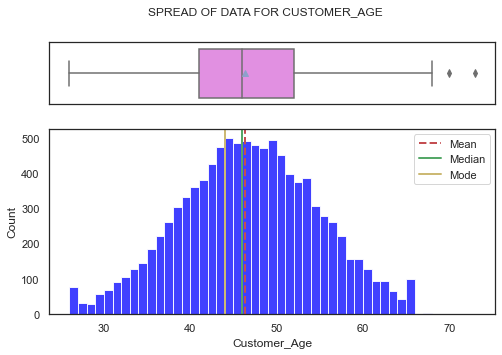

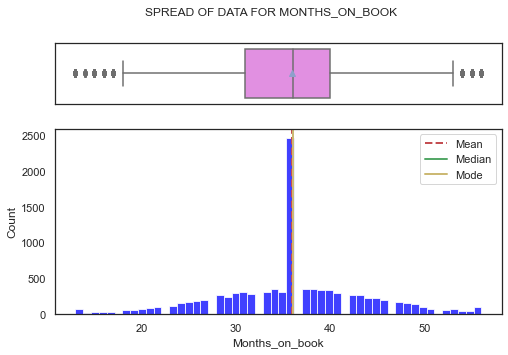

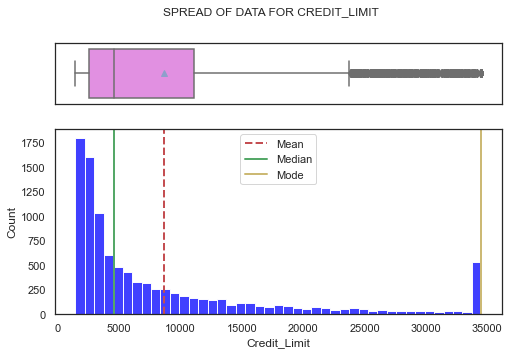

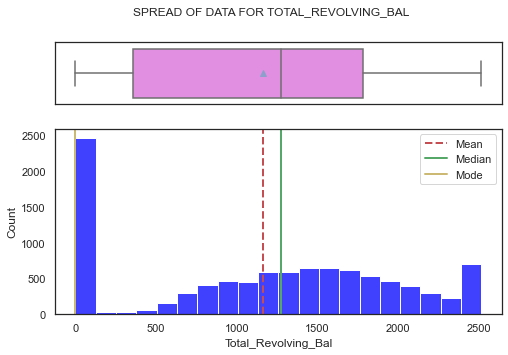

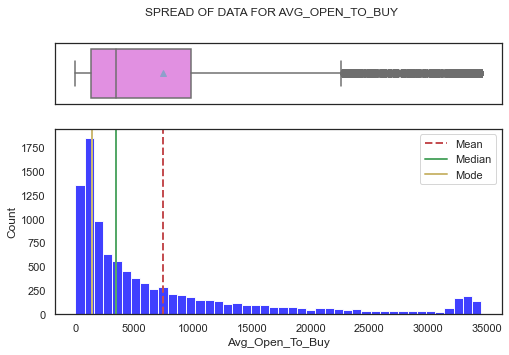

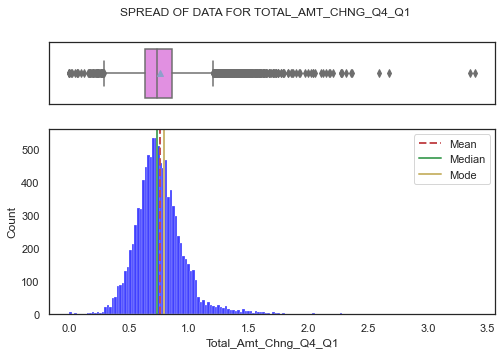

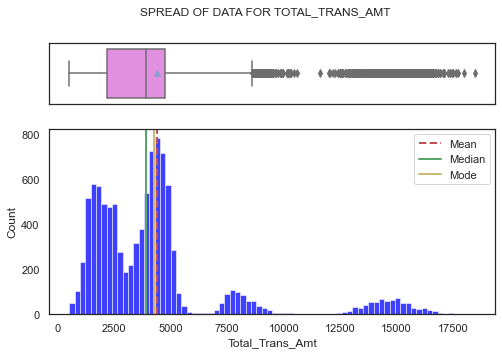

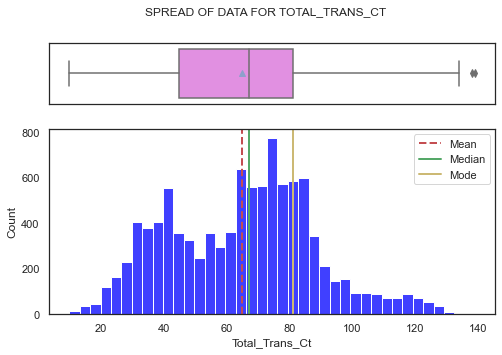

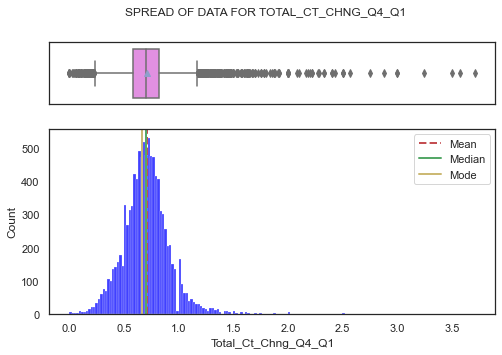

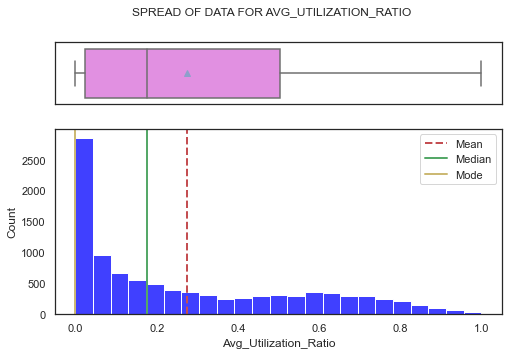

In [97]:
#select all quantitative columns for checking the spread
list_col=  df.select_dtypes(include="number").columns.to_list()
for i in range(len(list_col)):
    UVar(df[list_col[i]])

### Customer age has a normal distribution
### Months on book also has a normal distribution, but there are several outliers on the lower and higher end. Several counts in the 35-36 range
### Credit card limit skews right, with a spike at 35000
### There are several customers who have 0 for their revolving balance. The data overall has a normal distribution though
### Average open to buy skews right then spikes before 35000, just like credit card limit
### There are several outliers for total amount change.
### Total trans amount has several outliers, with notable peals at 7500-10000 and 12500-17500
### Total trans counth has a few outliers, but is overall normal
### Total ct change has several outliers
### Avg utilization skews to the right

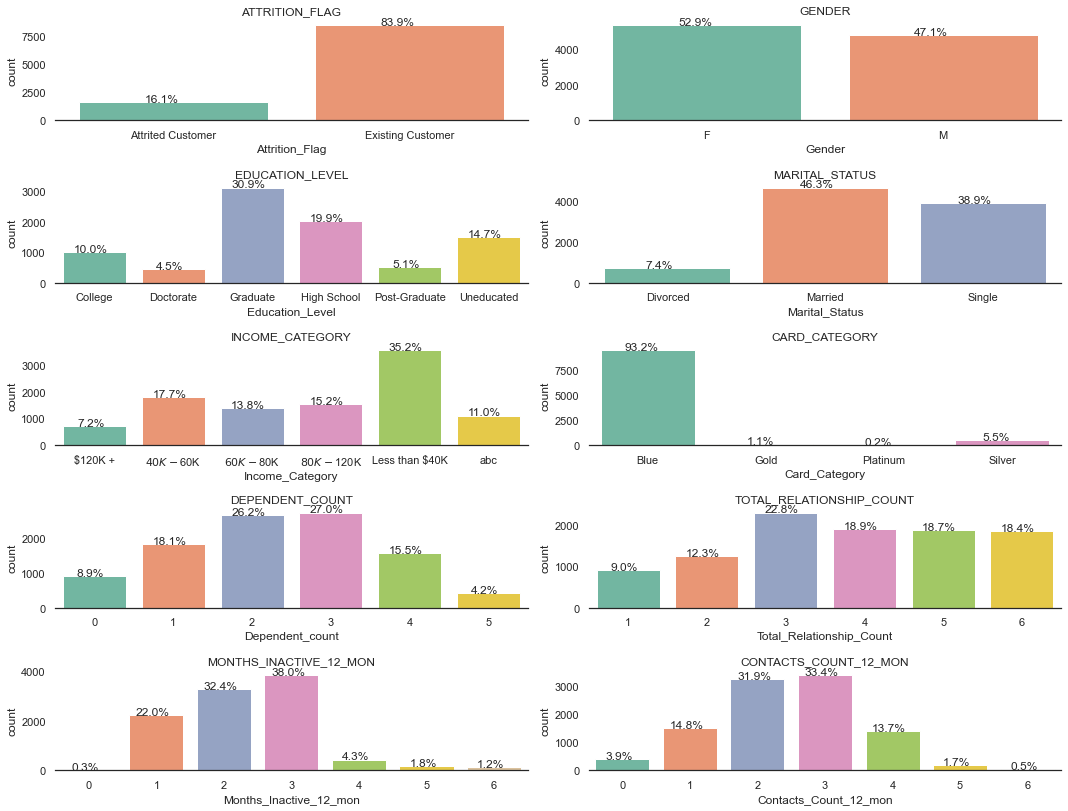

In [21]:
#List of all categorical variables

plt.figure(figsize=(15,20))

sns.set_theme(style="white") 
for i, variable in enumerate(cat_cols):
                     plt.subplot(9,2,i+1)
                     order = df[variable].value_counts(ascending=False).index   
                     #sns.set_palette(list_palette[i]) # to set the palette
                     sns.set_palette("Set2")
                     ax=sns.countplot(x=df[variable], data=df )
                     sns.despine(top=True,right=True,left=True) # to remove side line from graph
                     for p in ax.patches:
                           percentage = "{:.1f}%".format(100 * p.get_height()/len(df[variable]))
                           x = p.get_x() + p.get_width() / 2 - 0.05
                           y = p.get_y() + p.get_height()
                           plt.annotate(percentage, (x, y),ha="center")
                     plt.tight_layout()
                     plt.title(cat_cols[i].upper())
                                     

### 16% of customers attrited
### 53% of customers are female
### 31% of customers are graduates. postgrad and doctorate customers are rare
### 46% of customers are married
### 35% of customers earn less than 40k 
### 93% of customers own the blue card, while less than 1% own the platinum card
### 22% of customers have more than 3 bank accounts
### 38% of customers are inactive at 3 months. Customers that are inactive past this might make up the attrited customers
### 32% of customers are contacted twice a year while 33% of customers are contacted thrice a year

## Multivariate Analysis

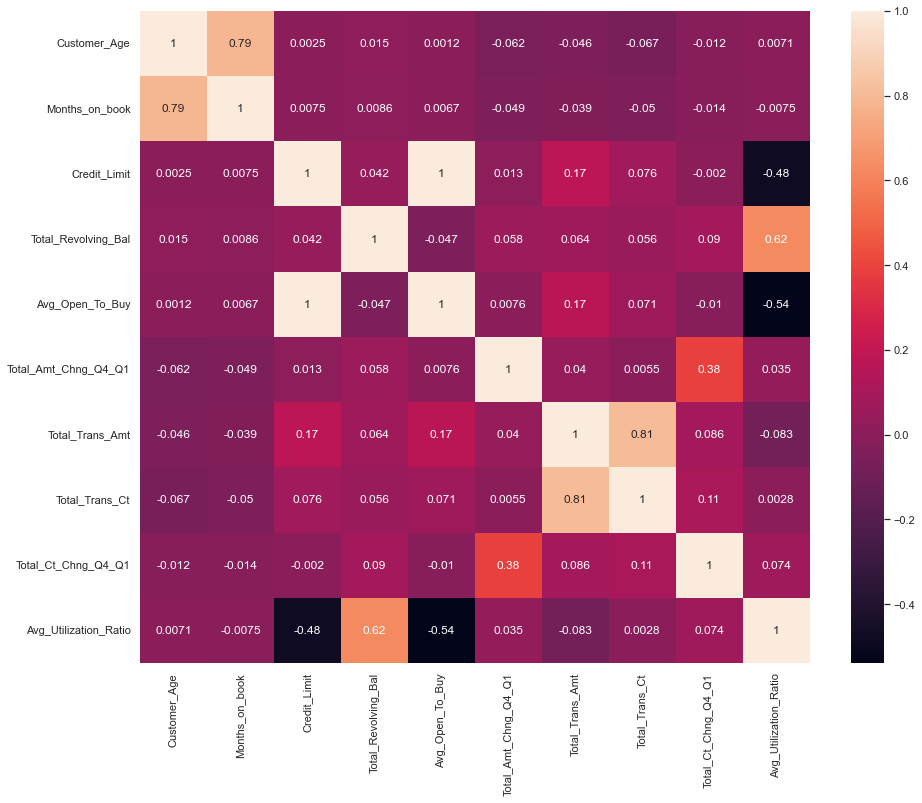

In [22]:
#Let's create a heatmap to look for any correlations
plt.figure(figsize=(15,12))
sns.heatmap(df.corr(),annot=True)
plt.show()  

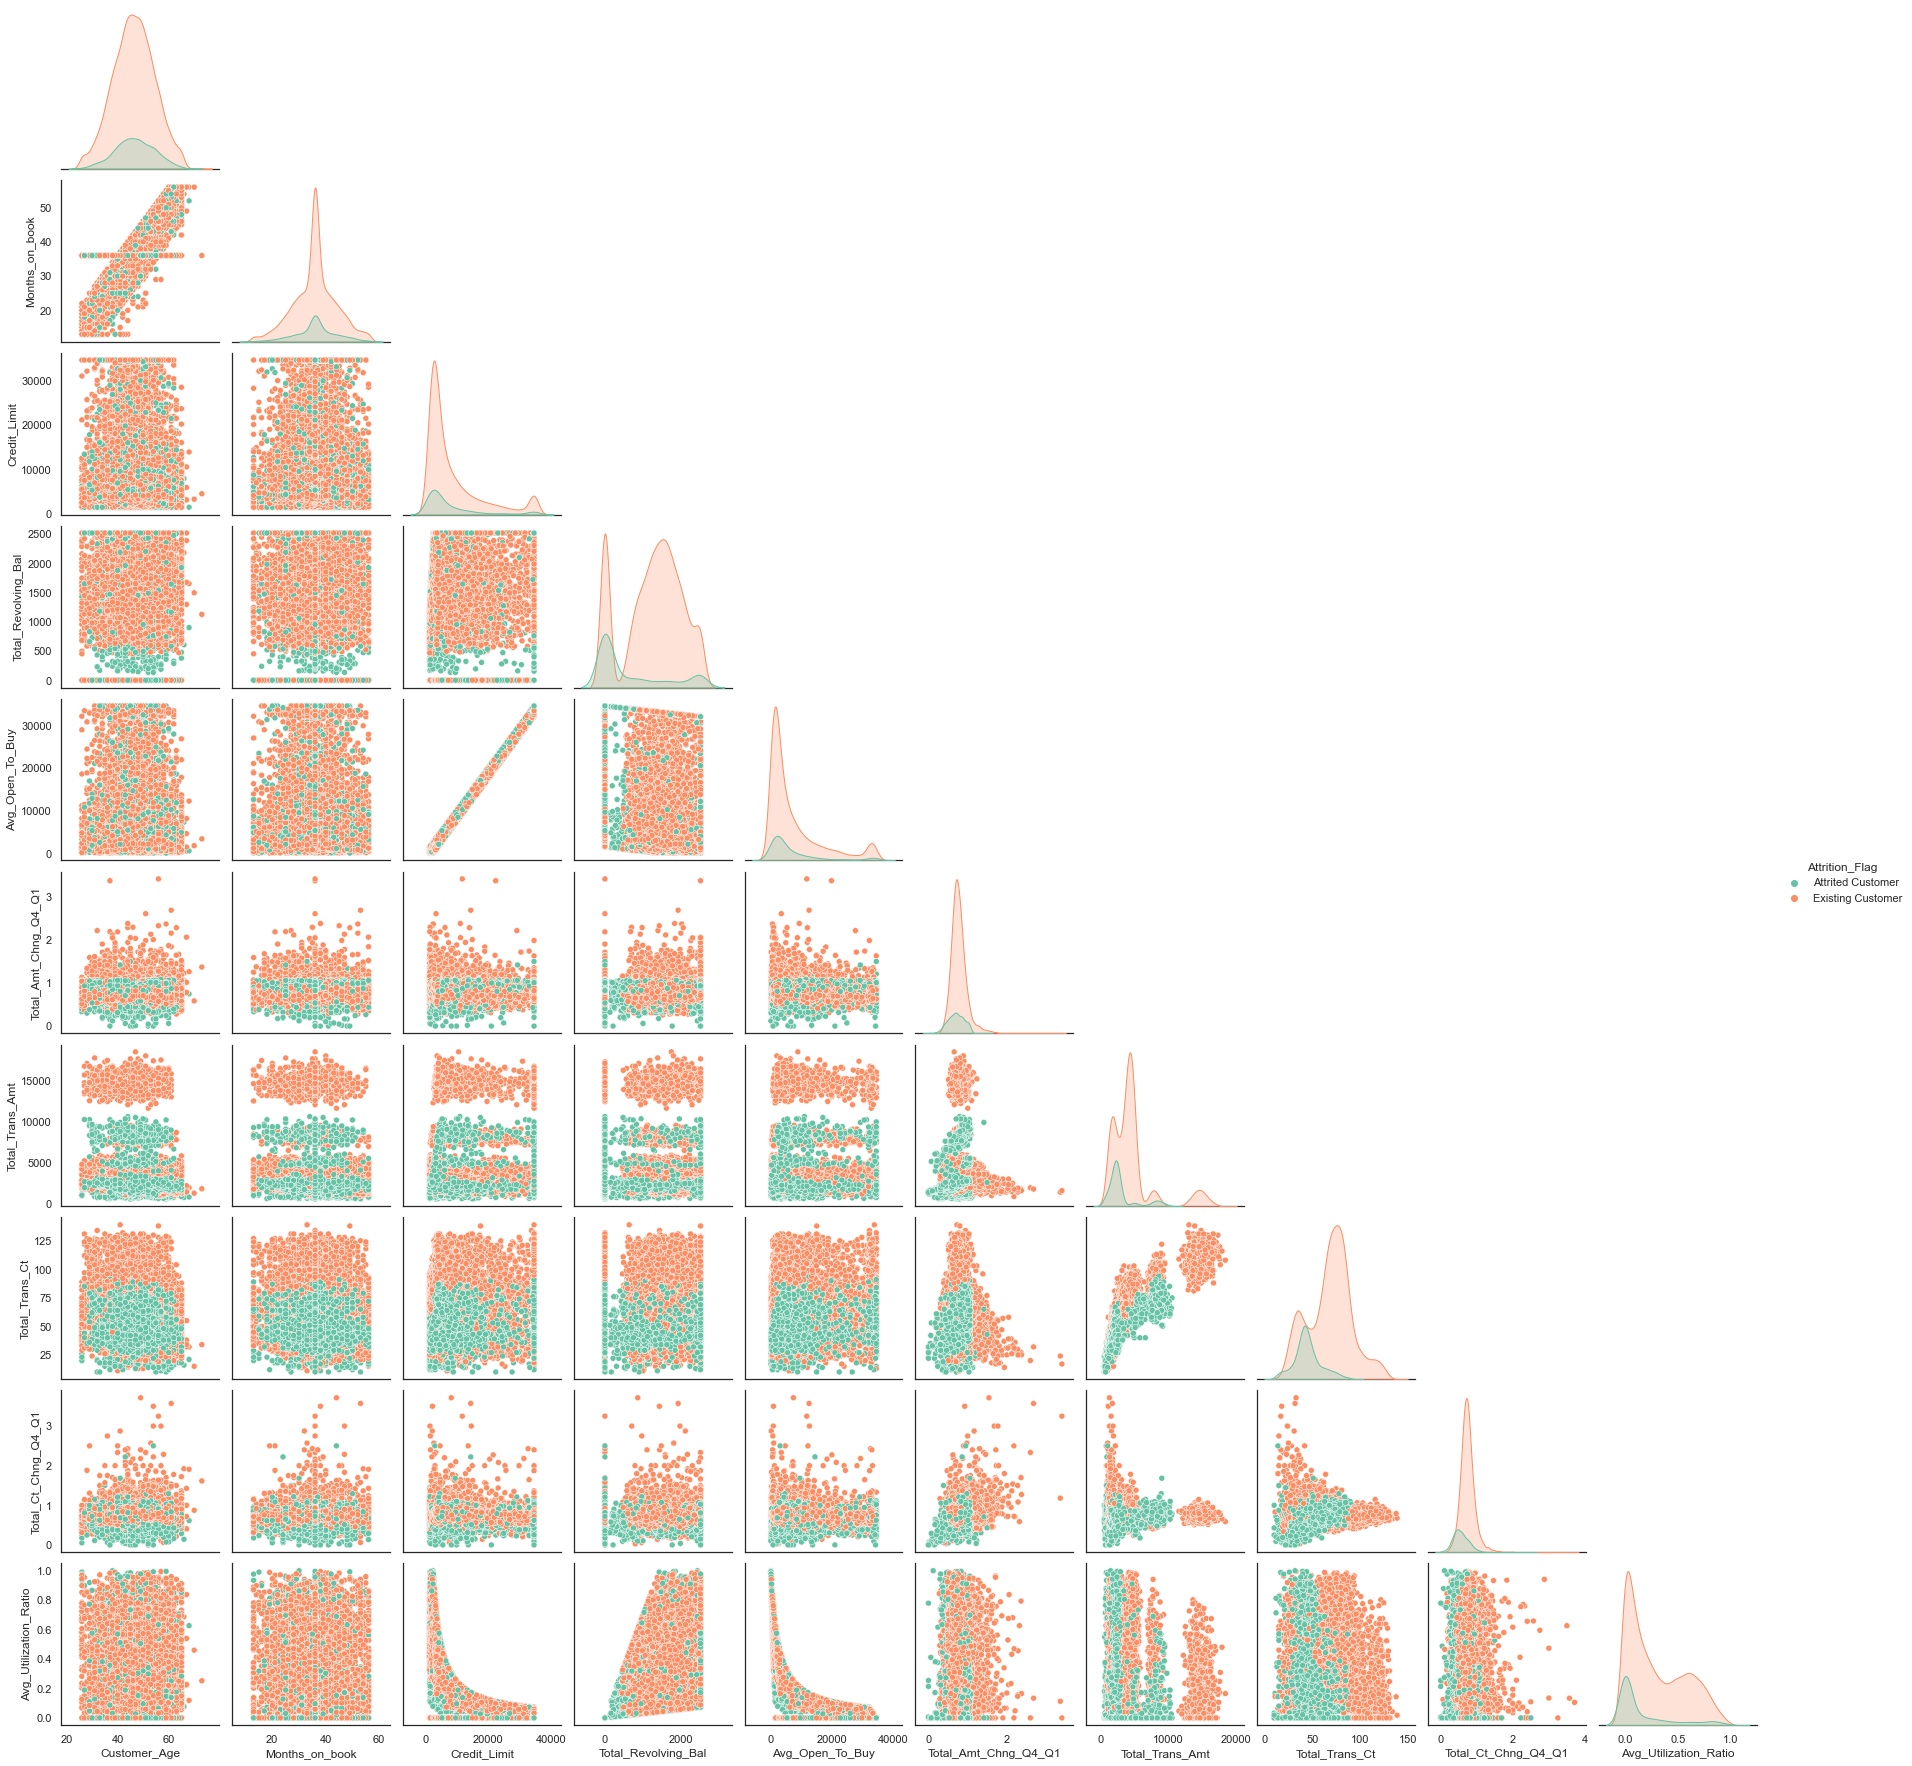

In [23]:
#Let's follow up with a pairplot to visualize the correlations
sns.pairplot(df, hue="Attrition_Flag",corner=True)
plt.show()

### Perfect 1:1 correlation for credit limit and average open to buy
### Strong positive correlation between customer age and number of books
### Strong positive correlation between total transfer amount and total transfer count
### Positive correlation between total revolving balance and average utilization
### Negative correlation between credit card limit and average utilization
### Negative correlation betwen average opening balance and average utlization ratio
### No correlation between total transfer amount and credit limit

In [98]:
#Function to plot distributions and Boxplots of customers
def plot(x,target="Attrition_Flag"):
    fig,axs = plt.subplots(2,2,figsize=(12,10))
    axs[0, 0].set_title(f"Distribution of {x} \n of a existing customer",fontsize=12,fontweight="bold")
    sns.histplot(df[(df[target] == "Existing Customer")][x],ax=axs[0,0],color="red")
    axs[0, 1].set_title(f"Distribution of {x}\n of a  attrited customer ",fontsize=12,fontweight="bold")
    sns.histplot(df[(df[target] == "Attrited Customer")][x],ax=axs[0,1],color="blue")
    axs[1,0].set_title(f"Boxplot of {x} w.r.t attrited customer",fontsize=12,fontweight="bold")
    
    
    line = plt.Line2D((.1,.9),(.5,.5), color="grey", linewidth=1.5,linestyle="--")
    fig.add_artist(line)
   
    sns.boxplot(df[target],df[x],ax=axs[1,0],showmeans=True)
    axs[1,1].set_title(f"Boxplot of {x} w.r.t Product Taken - Without outliers",fontsize=12,fontweight="bold")
    sns.boxplot(df[target],df[x],ax=axs[1,1],showfliers=False,palette="gist_rainbow",showmeans=True) #turning off outliers from boxplot
    sns.despine(top=True,right=True,left=True) # to remove side line from graph
    plt.tight_layout(pad=4)
    plt.show()

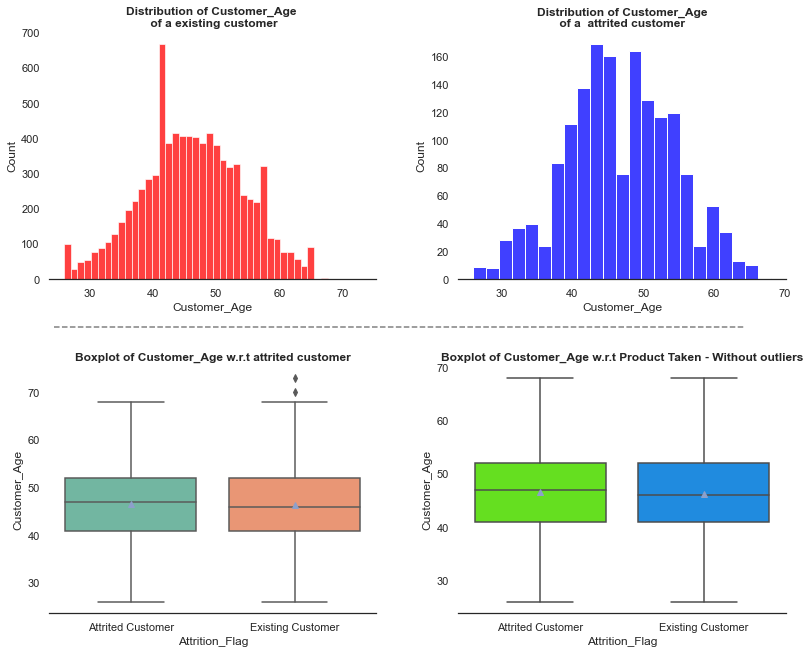

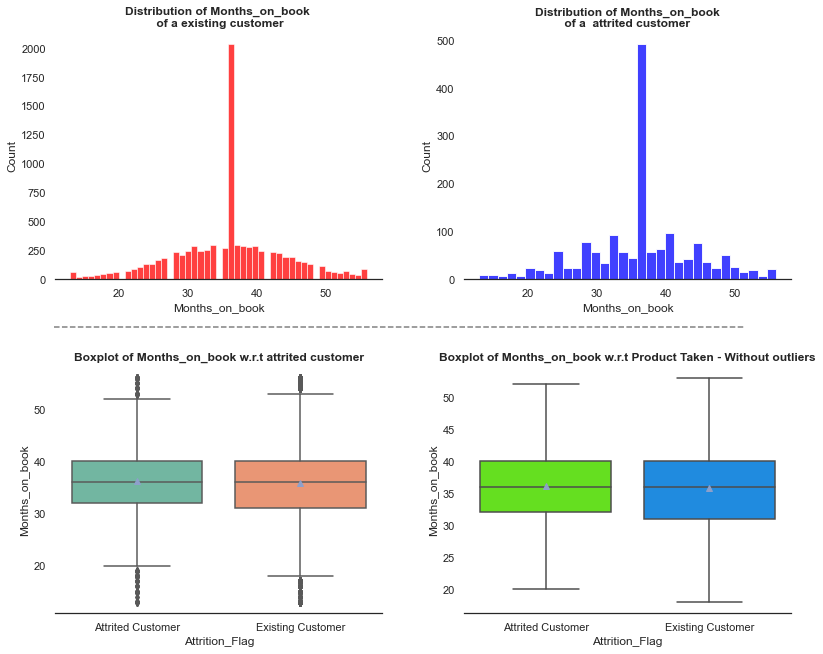

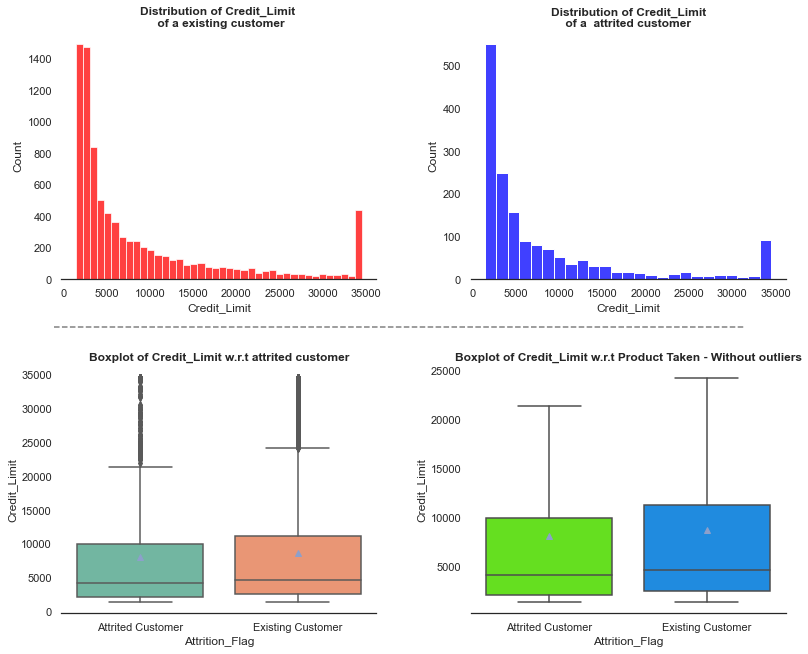

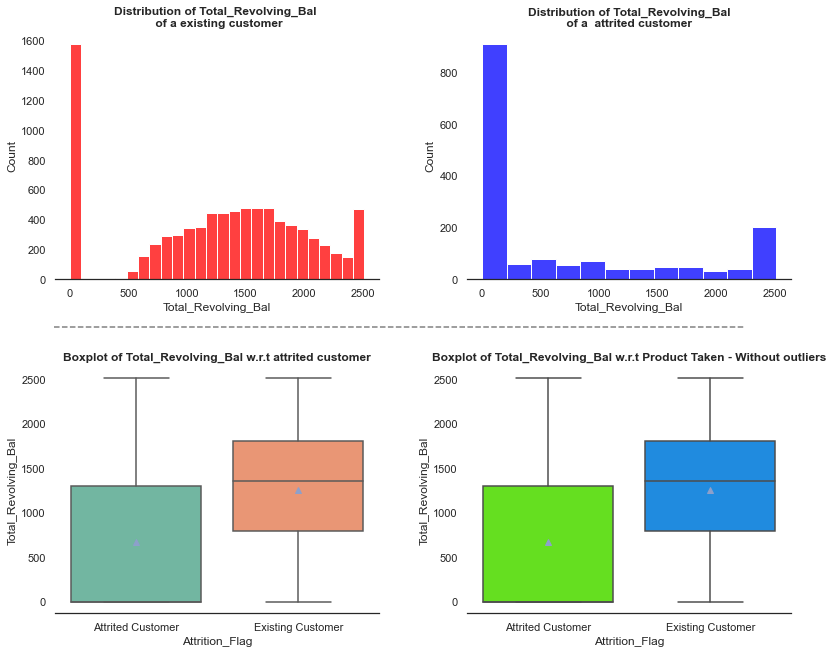

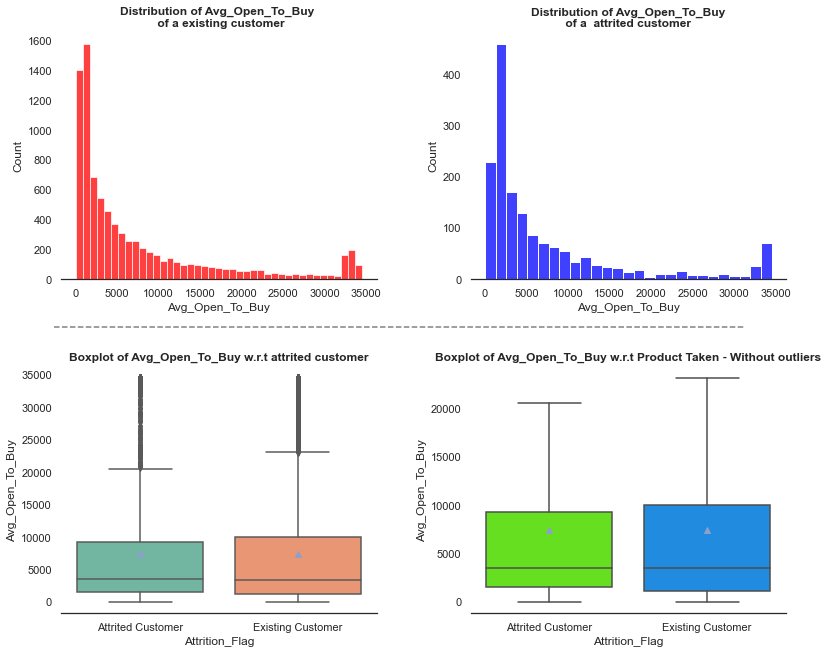

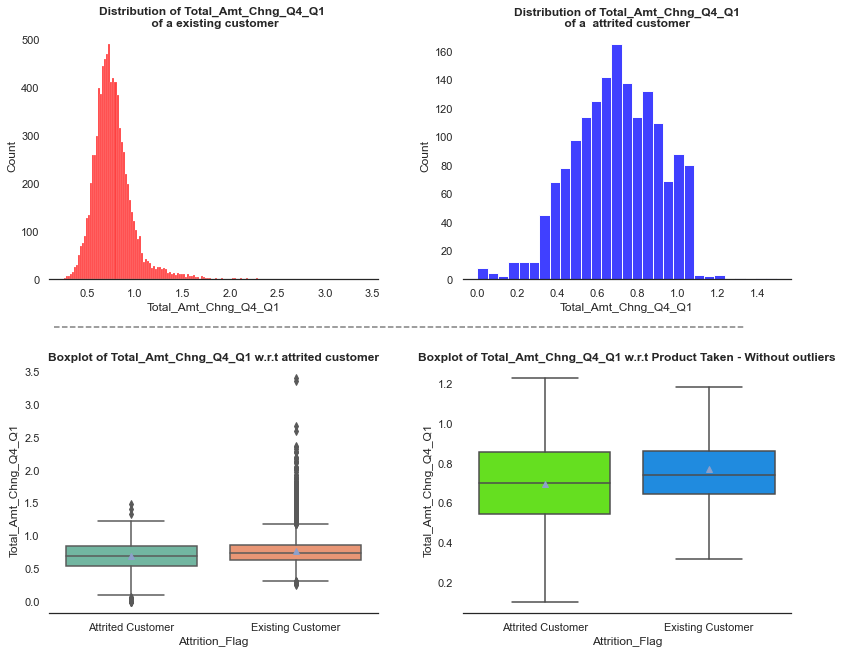

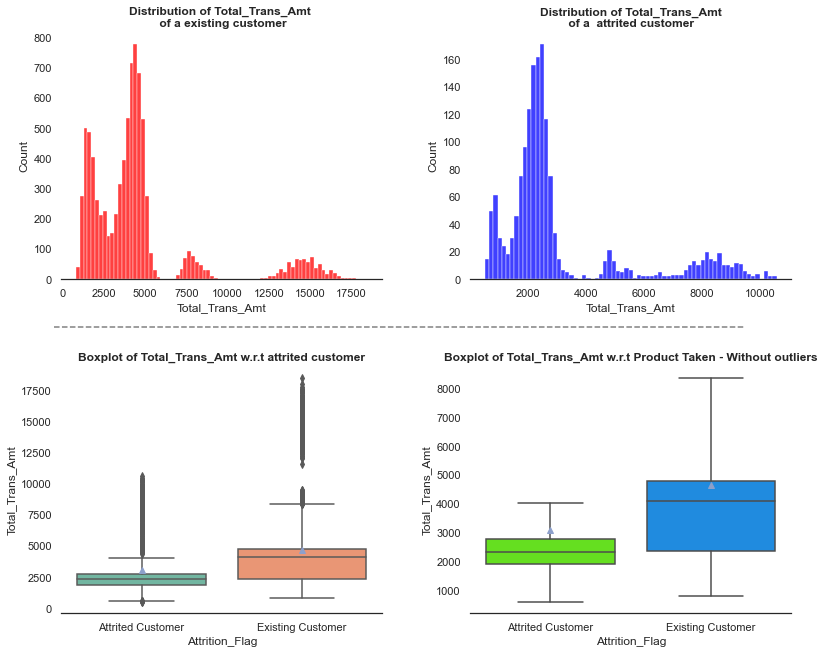

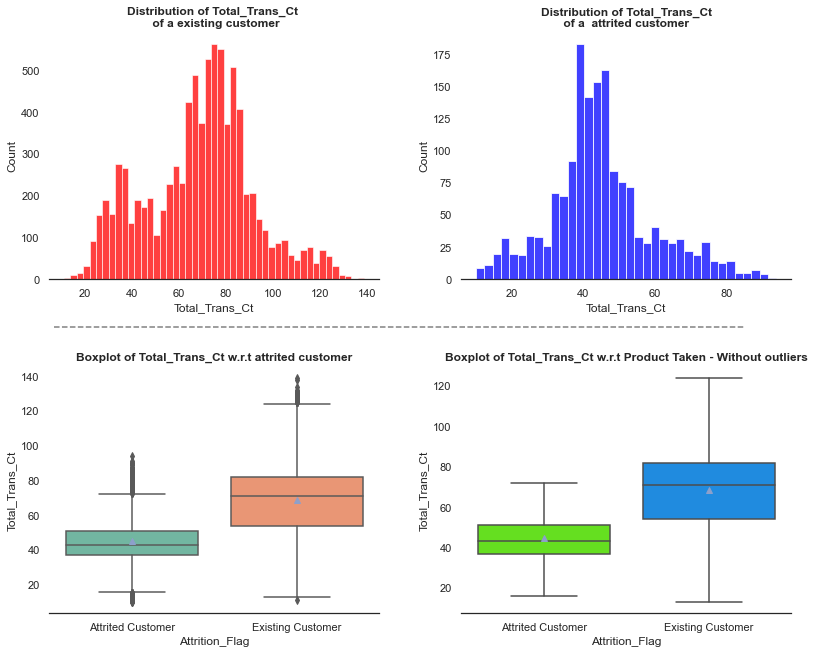

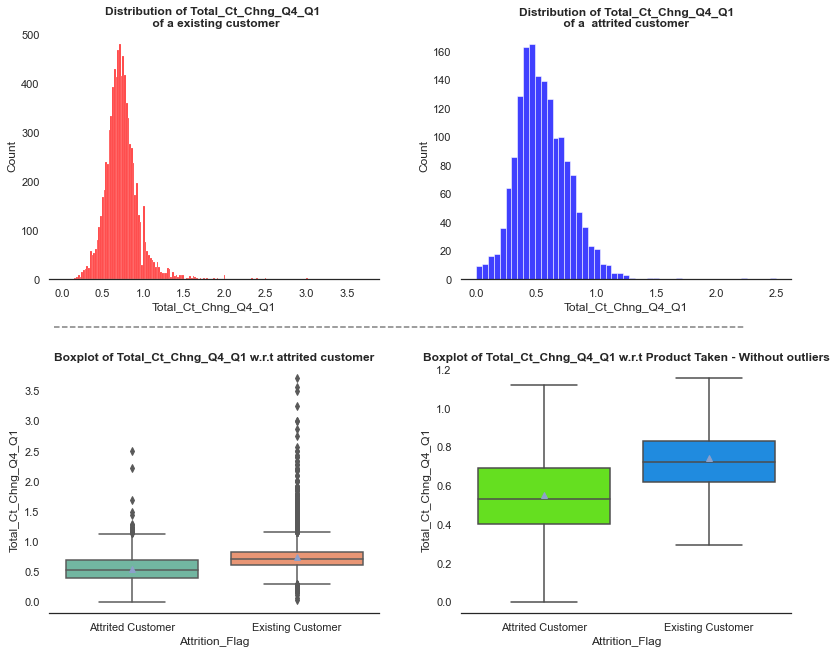

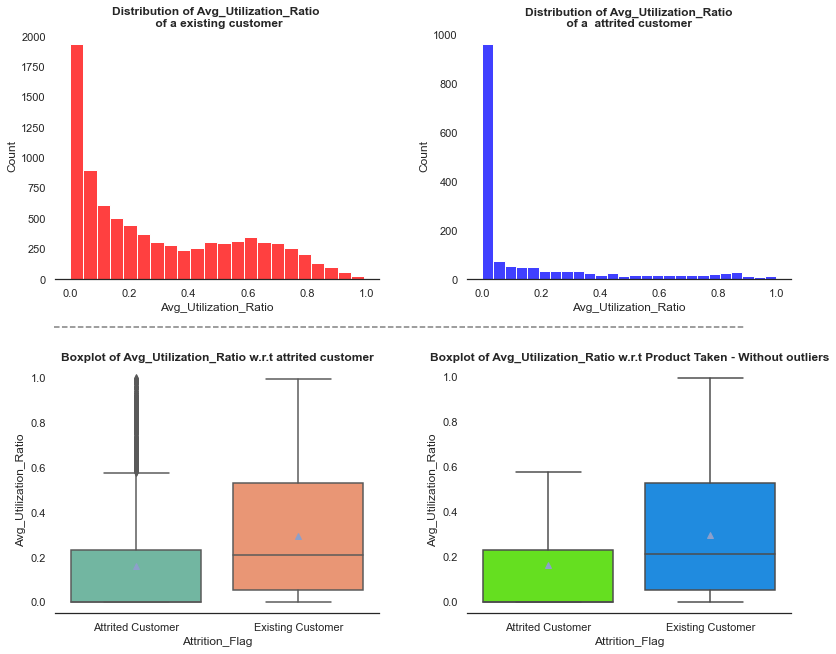

In [99]:
#select all quantitative columns for checking the spread
#list_col=  ["Age","DurationOfPitch","MonthlyIncome"]
list_col=df.select_dtypes(include="number").columns.to_list()
#print(list_col)
#plt.figure(figsize=(14,23))
for j in range(len(list_col)):
   plot(list_col[j])

### No difference in age, months on book, credit limit, average open to buy, and attrited vs existing customers
### Existing customers have higher total revolving balance than attrited customers
### Customers with lower transaction amounts spent and lower changes in transaction_spend_Q1_Q4 are more likely to attrite
### Customers with low number of transactions and low change in number of transactions between Q1 and Q4 are more likely to attrite
### Customers with less utlization are more likely to attrite

Text(0.5, 1.0, 'Income vs credit')

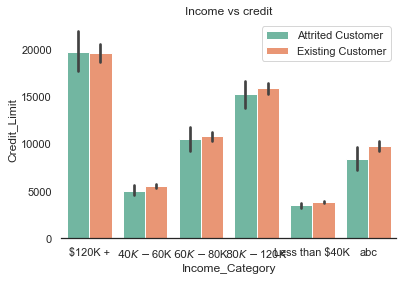

In [28]:
#Bar graph showing attrition by comparing income category with credit limit
sns.barplot(y="Credit_Limit",x="Income_Category",hue="Attrition_Flag",data=df)
sns.despine(top=True,right=True,left=True)
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("Income vs credit")

Text(0.5, 1.0, 'CustomerAge  vs Education')

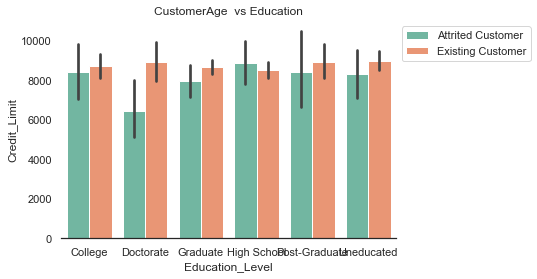

In [29]:
#Bar graph showing attrition by comparing education level with credit limit
sns.barplot(y="Credit_Limit",x="Education_Level",hue="Attrition_Flag",data=df)
sns.despine(top=True,right=True,left=True)
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("CustomerAge  vs Education")

Text(0.5, 1.0, 'CustomerAge  vs Credit limit')

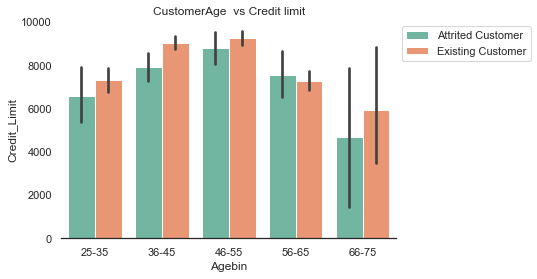

In [30]:
#Bar graph showing attrition by comparing customer age with credit limit
sns.barplot(x="Agebin",y="Credit_Limit",hue="Attrition_Flag",data=df)
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("CustomerAge  vs Credit limit")

Text(0.5, 1.0, 'CustomerAge  vs Total Revolving Balance')

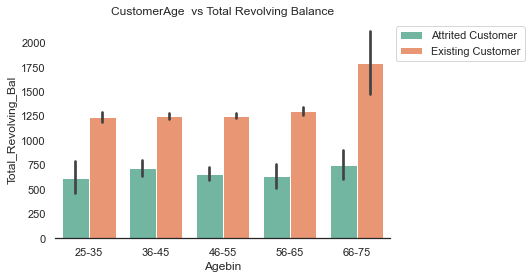

In [31]:
#Bar graph showing attrition by comparing age with total revolving balance
sns.barplot(x="Agebin",y="Total_Revolving_Bal",hue="Attrition_Flag",data=df)
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("CustomerAge  vs Total Revolving Balance")

Text(0.5, 1.0, 'CustomerAge  vs Total Transcational Amount')

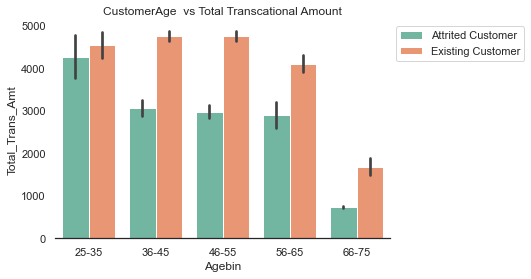

In [32]:
#Bar graph showing attrition by comparing age with total transaction amounts
sns.barplot(x="Agebin",y="Total_Trans_Amt",hue="Attrition_Flag",data=df)
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("CustomerAge  vs Total Transcational Amount")

Text(0.5, 1.0, 'Credit limit  vs Gender')

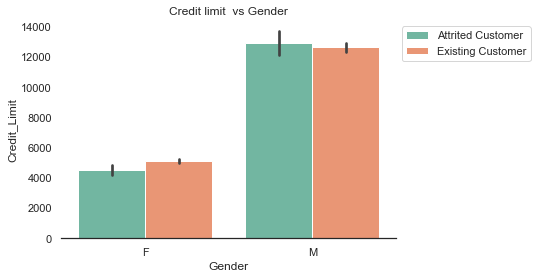

In [33]:
#Bar graph showing attrition by comparing gender with credit limit
sns.barplot(y="Credit_Limit",x="Gender",hue="Attrition_Flag",data=df) 
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("Credit limit  vs Gender")

Text(0.5, 1.0, 'Credit Limit  vs Card Category')

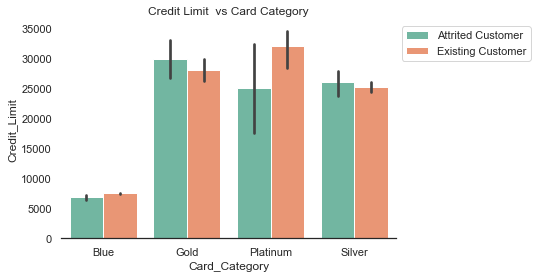

In [34]:
#Bar graph showing attrition by comparing card category with credit limit
sns.barplot(y="Credit_Limit",x="Card_Category",hue="Attrition_Flag",data=df) 
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("Credit Limit  vs Card Category")

Text(0.5, 1.0, 'Total Transcation Count  vs Card Category')

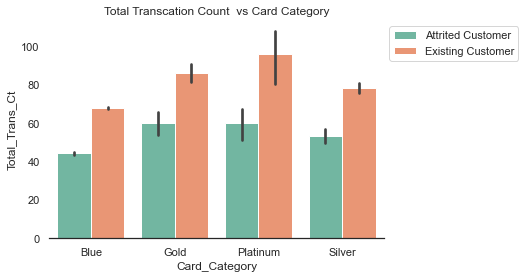

In [35]:
#Bar graph comparing total transactional counts with card categories
sns.barplot(y="Total_Trans_Ct",x="Card_Category",hue="Attrition_Flag",data=df) 
sns.despine(top=True,right=True,left=True) # to remove side line from graph
plt.legend(bbox_to_anchor=(1.00, 1))
plt.title("Total Transcation Count  vs Card Category")

### Middle age customers (35-55) were given larger credit limits than other groups
### Platinum card holders had higher credit limits
### Customers with incomes over 120K have higher credit limits
### Male customers were given larger credit limits than female customers

In [119]:
#Function to create stacked bar plot to show final comparisons and results
def stacked_plot(x):
    sns.set_palette(sns.color_palette("tab20", 8))
    tab1 = pd.crosstab(x,df["Attrition_Flag"],margins=True)
    display(tab1)
    tab = pd.crosstab(x,df["Attrition_Flag"],normalize="index")
    tab.plot(kind="bar",stacked=True,figsize=(9,5))
    plt.xticks(rotation=360)
    #labels=["No","Yes"]
    plt.legend(loc="lower left", frameon=False,)
    plt.legend(loc="upper left",title=" ",bbox_to_anchor=(1,1))
    sns.despine(top=True,right=True,left=True) # to remove side line from graph
    #plt.legend(labels)
    plt.show()

Attrition_Flag,Attrited Customer,Existing Customer,All
Attrition_Flag,,,
Attrited Customer,1627,0,1627
Existing Customer,0,8500,8500
All,1627,8500,10127


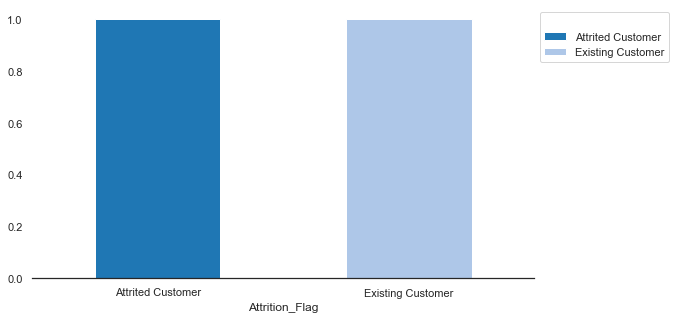

Attrition_Flag,Attrited Customer,Existing Customer,All
Gender,,,
F,930,4428,5358
M,697,4072,4769
All,1627,8500,10127


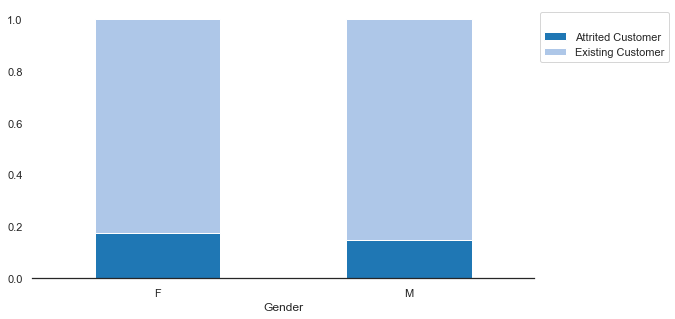

Attrition_Flag,Attrited Customer,Existing Customer,All
Education_Level,,,
College,154,859,1013
Doctorate,95,356,451
Graduate,487,2641,3128
High School,306,1707,2013
Post-Graduate,92,424,516
Uneducated,237,1250,1487
All,1371,7237,8608


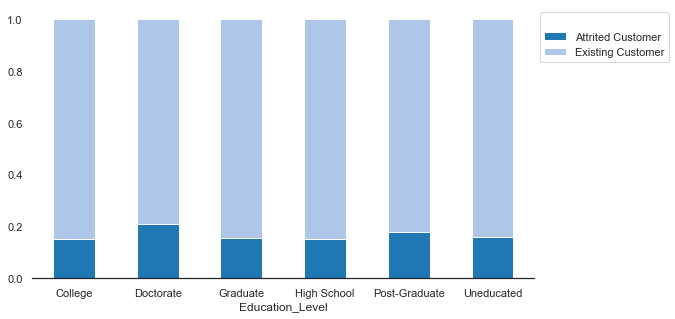

Attrition_Flag,Attrited Customer,Existing Customer,All
Marital_Status,,,
Divorced,121,627,748
Married,709,3978,4687
Single,668,3275,3943
All,1498,7880,9378


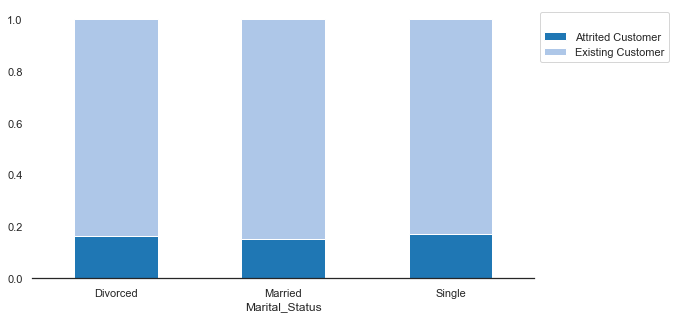

Attrition_Flag,Attrited Customer,Existing Customer,All
Income_Category,,,
$120K +,126,601,727
$40K - $60K,271,1519,1790
$60K - $80K,189,1213,1402
$80K - $120K,242,1293,1535
Less than $40K,612,2949,3561
abc,187,925,1112
All,1627,8500,10127


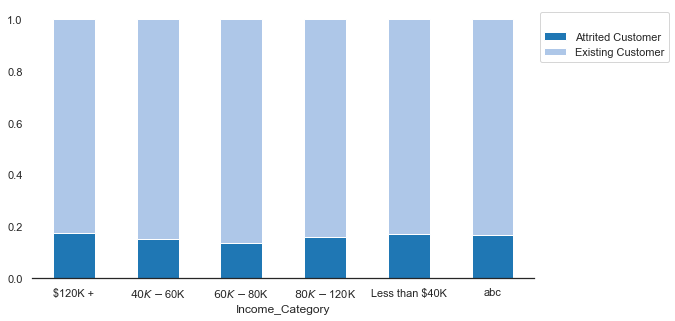

Attrition_Flag,Attrited Customer,Existing Customer,All
Card_Category,,,
Blue,1519,7917,9436
Gold,21,95,116
Platinum,5,15,20
Silver,82,473,555
All,1627,8500,10127


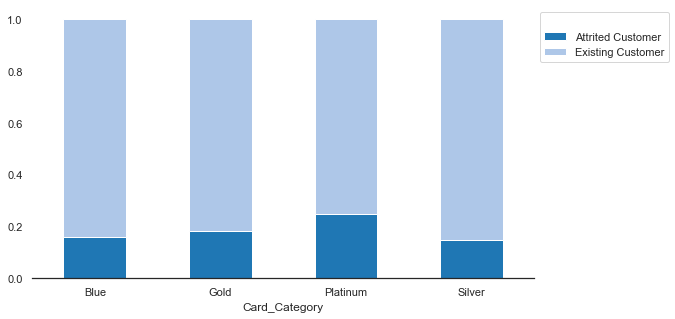

Attrition_Flag,Attrited Customer,Existing Customer,All
Dependent_count,,,
0,135,769,904
1,269,1569,1838
2,417,2238,2655
3,482,2250,2732
4,260,1314,1574
5,64,360,424
All,1627,8500,10127


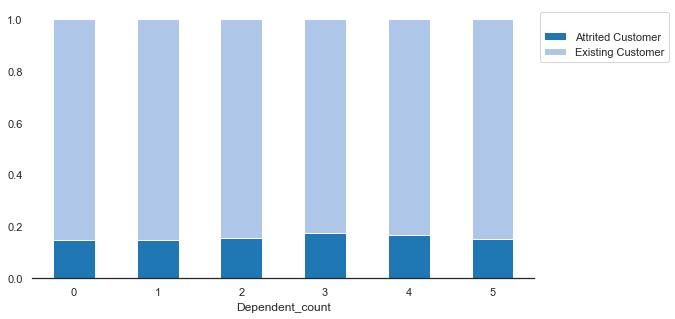

Attrition_Flag,Attrited Customer,Existing Customer,All
Total_Relationship_Count,,,
1,233,677,910
2,346,897,1243
3,400,1905,2305
4,225,1687,1912
5,227,1664,1891
6,196,1670,1866
All,1627,8500,10127


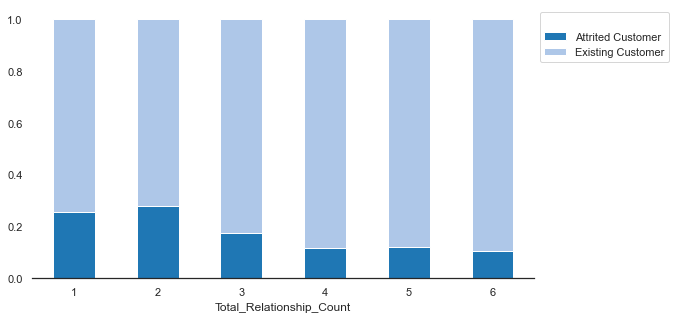

Attrition_Flag,Attrited Customer,Existing Customer,All
Months_Inactive_12_mon,,,
0,15,14,29
1,100,2133,2233
2,505,2777,3282
3,826,3020,3846
4,130,305,435
5,32,146,178
6,19,105,124
All,1627,8500,10127


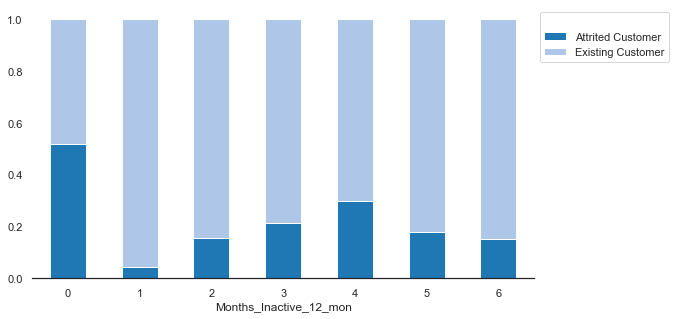

Attrition_Flag,Attrited Customer,Existing Customer,All
Contacts_Count_12_mon,,,
0,7,392,399
1,108,1391,1499
2,403,2824,3227
3,681,2699,3380
4,315,1077,1392
5,59,117,176
6,54,0,54
All,1627,8500,10127


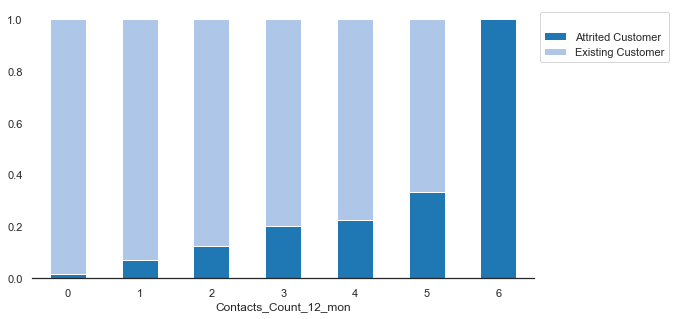

Attrition_Flag,Attrited Customer,Existing Customer,All
Agebin,,,
25-35,122,797,919
36-45,606,3136,3742
46-55,688,3447,4135
56-65,209,1112,1321
66-75,2,8,10
All,1627,8500,10127


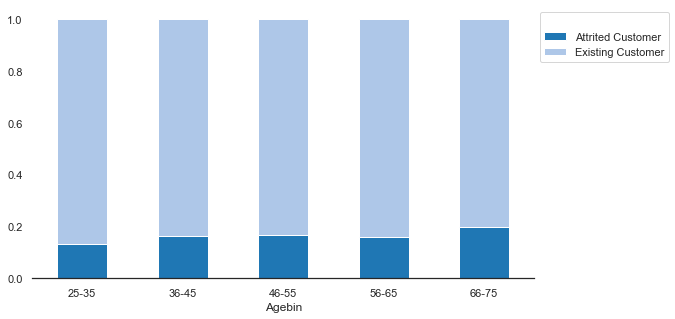

In [120]:
cat_cols.append("Agebin")
for i, variable in enumerate(cat_cols):
       stacked_plot(df[variable])

### Female customers attrited more than male customers
### Educated customers (postgrad or doctorate) attrited more than less educated customers
### Single customers attrited more
### Gold card customers attrited more than blue and silver card customers
### Customers with 3 dependents attrited more
### Customers having 1 or 2 bank products attrited more compared to customers with more bank products
### Customers who were never inactive attrited most. Customers who were inactive for 4 months attrited most followed by 3 month and 5 month.
### Customers who were contacted most in last 12 month attrited.
### Older customers(66-75) attrited the most, but we have only 18 samples. Middle age customers (36-55) overall attrited more.

## Customer Profiles

### Gold Card

In [37]:
#Profile of Attrited Customer with gold card 
df[(df["Card_Category"]=="Gold") & (df["Attrition_Flag"]=="Attrited Customer")].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Attrition_Flag,21,1,Attrited Customer,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,21.0,NaN,NaN,NaN,43.857143,6.223228,32.0,41.0,44.0,47.0,59.0
Gender,21,2,M,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,21.0,6.0,2.0,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,17,6,Graduate,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,17,2,Single,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,21,6,$60K - $80K,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,21,1,Gold,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,21.0,NaN,NaN,NaN,33.904762,6.155524,20.0,32.0,36.0,36.0,48.0
Total_Relationship_Count,21.0,6.0,2.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Most likely customers are single males between 36-45 earning 60- 80k.  Graduate level education and inactive for 3 months

### Silver Card

In [38]:
#Profile of Attrited Customer with silver Card 
df[(df["Card_Category"]=="Silver") & (df["Attrition_Flag"]=="Attrited Customer")].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Attrition_Flag,82,1,Attrited Customer,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,82.0,NaN,NaN,NaN,47.158537,7.470881,30.0,42.25,48.0,52.0,65.0
Gender,82,2,M,54,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,82.0,6.0,2.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,73,6,Graduate,28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,77,3,Single,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,82,6,$80K - $120K,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,82,1,Silver,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,82.0,NaN,NaN,NaN,36.365854,7.721242,18.0,33.0,36.0,42.75,56.0
Total_Relationship_Count,82.0,6.0,2.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Most likely customers are single males between 46-55 earning 80-120k. Graduate level education and inactive for 3 months

### Platinum Card

In [124]:
#Profile of Attrited Customer with platinum Card 
df[(df["Card_Category"]=="Platinum") & (df["Attrition_Flag"]=="Attrited Customer")].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Attrition_Flag,5,1,Attrited Customer,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,5.00000,NaN,NaN,NaN,49.40000,4.15933,43.00000,48.00000,51.00000,51.00000,54.00000
Gender,5,2,F,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependent_count,5.00000,4.00000,2.00000,2.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education_Level,5,3,Graduate,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Marital_Status,5,2,Single,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Income_Category,5,3,Less than $40K,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Card_Category,5,1,Platinum,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Months_on_book,5.00000,NaN,NaN,NaN,36.00000,4.52769,31.00000,32.00000,37.00000,38.00000,42.00000
Total_Relationship_Count,5.00000,3.00000,2.00000,3.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Most likely customers are single females between 46-55 earning less than 40k. Graduate level education and inactive for 3 months

##  Insights

### ~16% of total customers attrited, with females attriting more than males
### Customers who were single attrited more
### Customers who earned more than 120k and less than 40k attrited more than the customers in between
### Customers with gold attrited more compared to blue and silver card.
### Customers with platinum cards attrited more but the sample size is very small. 
### Middle age customers (36-55) attrited more.
### Post grad or doctorate customers attrited most.

# Outlier Detection

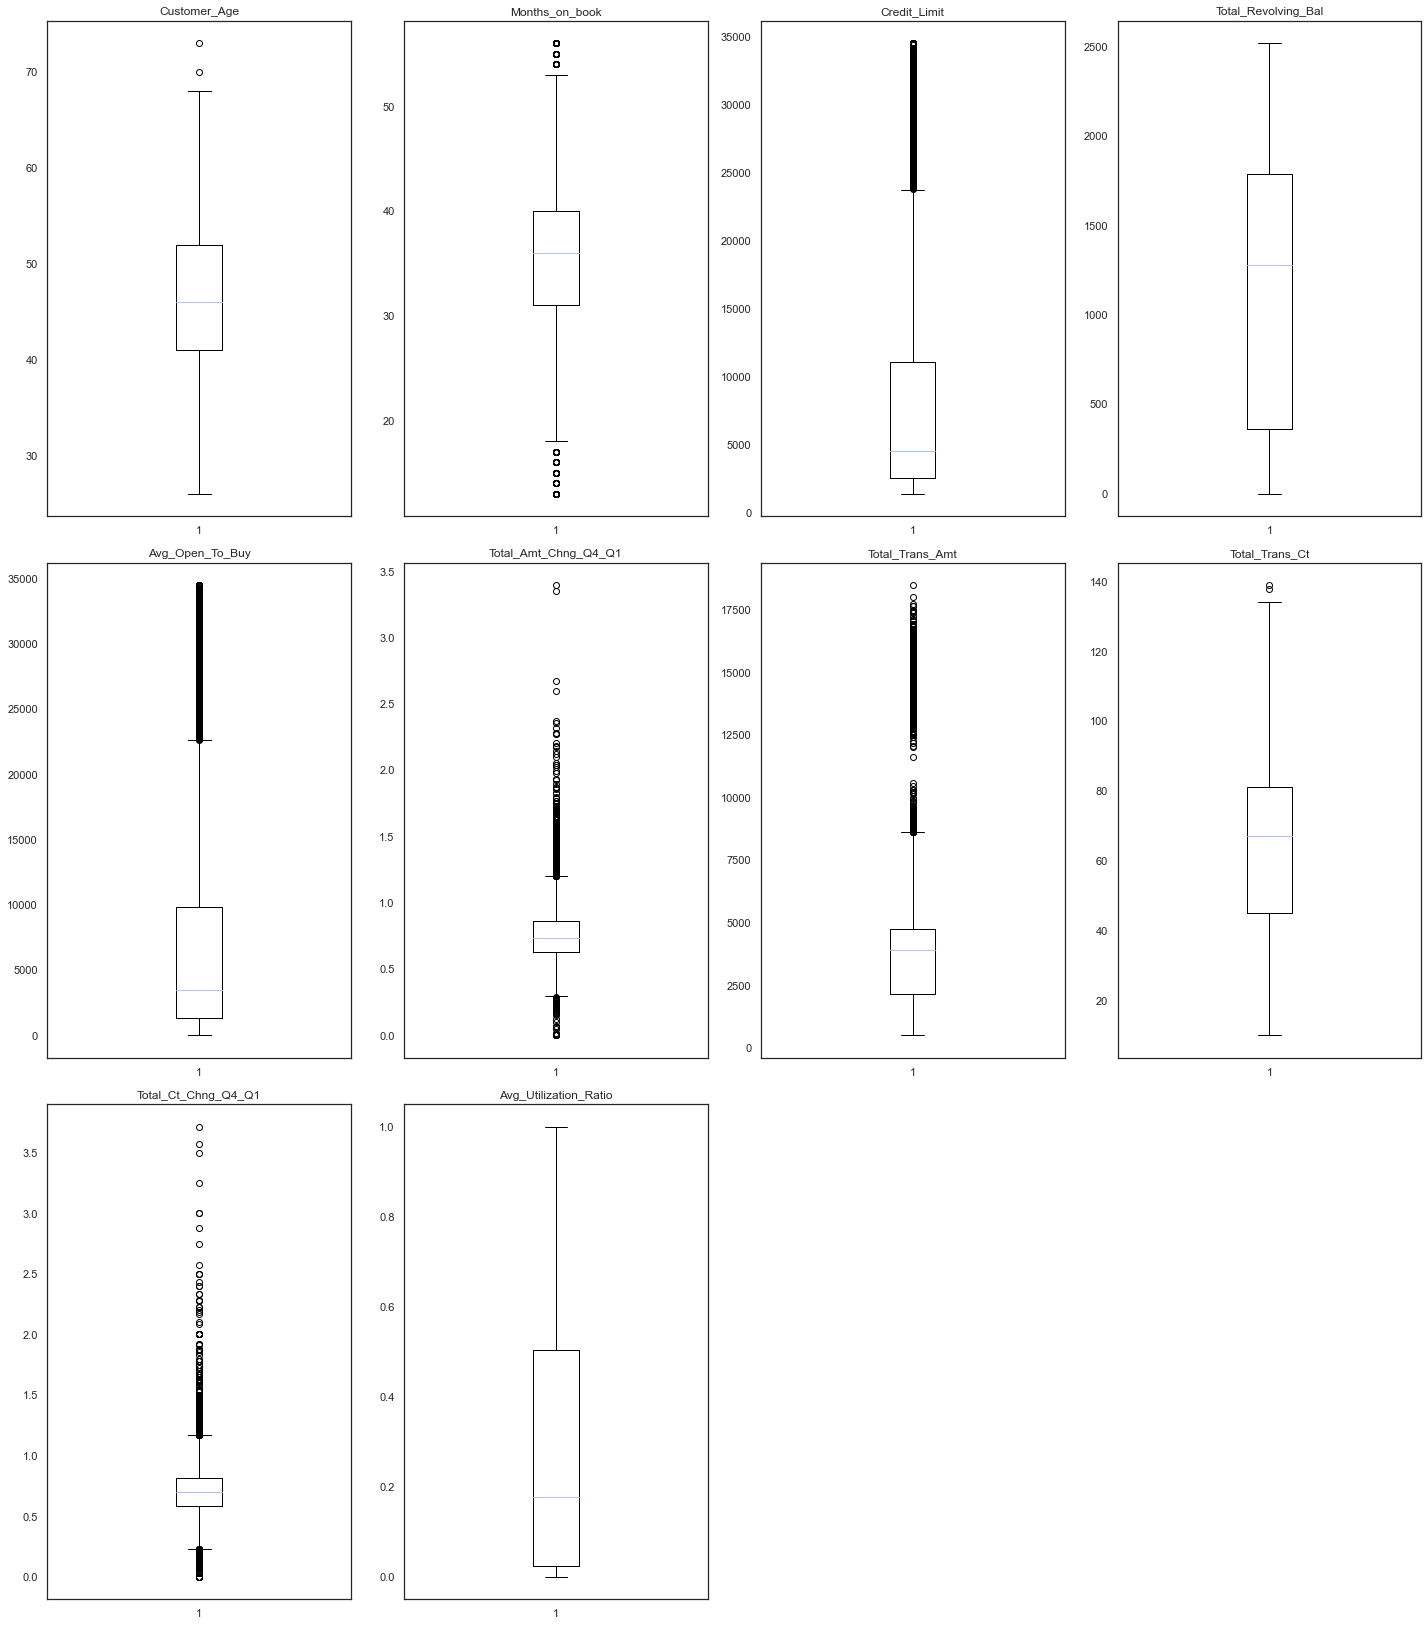

In [126]:
#Outlier detection using boxplot
numeric_columns = df.select_dtypes("number").columns.to_list()
plt.figure(figsize=(20,30))

for i, variable in enumerate(numeric_columns):
                     plt.subplot(4,4,i+1)
                     plt.boxplot(df[variable],whis=1.5)
                     plt.tight_layout()
                     plt.title(variable)

plt.show()

In [39]:
#Finding the 25th and 75th percentiles
Q1 = df.quantile(0.25)            
Q3 = df.quantile(0.75)

#Interquartile Range (75th perentile - 25th percentile)
IQR = Q3 - Q1                           

#Finding the lower and upper bounds for all values. Values outside these bounds are outliers
lower=Q1-1.5*IQR                        
upper=Q3+1.5*IQR

In [40]:
print(upper)

Customer_Age                68.500
Months_on_book              53.500
Credit_Limit             23836.250
Total_Revolving_Bal       3921.500
Avg_Open_To_Buy          22660.750
Total_Amt_Chng_Q4_Q1         1.201
Total_Trans_Amt           8619.250
Total_Trans_Ct             135.000
Total_Ct_Chng_Q4_Q1          1.172
Avg_Utilization_Ratio        1.223
dtype: float64


In [41]:
df[df["Credit_Limit"] > upper.Credit_Limit].sort_values(by="Credit_Limit",ascending=False ).count()

Attrition_Flag              984
Customer_Age                984
Gender                      984
Dependent_count             984
Education_Level             839
Marital_Status              897
Income_Category             984
Card_Category               984
Months_on_book              984
Total_Relationship_Count    984
Months_Inactive_12_mon      984
Contacts_Count_12_mon       984
Credit_Limit                984
Total_Revolving_Bal         984
Avg_Open_To_Buy             984
Total_Amt_Chng_Q4_Q1        984
Total_Trans_Amt             984
Total_Trans_Ct              984
Total_Ct_Chng_Q4_Q1         984
Avg_Utilization_Ratio       984
Agebin                      984
dtype: int64

In [42]:
df[df["Credit_Limit"]== 34516.00000].count()

Attrition_Flag              508
Customer_Age                508
Gender                      508
Dependent_count             508
Education_Level             436
Marital_Status              468
Income_Category             508
Card_Category               508
Months_on_book              508
Total_Relationship_Count    508
Months_Inactive_12_mon      508
Contacts_Count_12_mon       508
Credit_Limit                508
Total_Revolving_Bal         508
Avg_Open_To_Buy             508
Total_Amt_Chng_Q4_Q1        508
Total_Trans_Amt             508
Total_Trans_Ct              508
Total_Ct_Chng_Q4_Q1         508
Avg_Utilization_Ratio       508
Agebin                      508
dtype: int64

In [69]:
df[df["Avg_Open_To_Buy"] > upper.Avg_Open_To_Buy].sort_values(by="Avg_Open_To_Buy",ascending=False ).head(10)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Agebin
10112,1,33,M,2,4.0,1.0,5.0,Gold,20,2,...,4,34516.0,0,34516.0,1.004,9338,73,0.622,0.0,25-35
9047,1,50,M,1,5.0,NaN,4.0,Gold,36,2,...,2,34516.0,0,34516.0,1.032,5547,75,0.744,0.0,46-55
2196,0,50,M,3,2.0,1.0,5.0,Blue,40,5,...,4,34516.0,0,34516.0,0.986,1930,36,0.440,0.0,46-55
2201,1,55,F,2,4.0,2.0,NaN,Silver,36,2,...,3,34516.0,0,34516.0,0.399,1353,40,0.212,0.0,46-55
9127,0,56,F,3,1.0,2.0,NaN,Platinum,46,2,...,2,34516.0,0,34516.0,0.887,8416,93,0.632,0.0,56-65
2341,0,52,M,1,NaN,2.0,5.0,Blue,44,6,...,2,34516.0,0,34516.0,1.030,2848,56,0.750,0.0,46-55
9075,0,51,M,3,1.0,1.0,4.0,Silver,37,1,...,1,34516.0,0,34516.0,0.814,8736,97,0.702,0.0,46-55
9073,0,39,M,2,NaN,2.0,4.0,Gold,33,1,...,2,34516.0,0,34516.0,0.724,9179,113,0.766,0.0,36-45
9068,1,54,F,0,3.0,2.0,NaN,Platinum,38,2,...,2,34516.0,0,34516.0,0.695,3901,54,0.421,0.0,46-55
9027,1,44,M,4,NaN,1.0,5.0,Blue,36,4,...,3,34516.0,0,34516.0,1.043,5425,60,0.875,0.0,36-45


In [47]:
df[df["Total_Trans_Amt"] > upper.Total_Trans_Amt].sort_values(by="Total_Trans_Amt",ascending=False ).head(10)

,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,...,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Agebin
9964,Existing Customer,47,M,4,NaN,Married,$60K - $80K,Blue,36,4,...,2,10585.0,1749,8836.0,0.655,18484,108,0.588,0.165,46-55
10073,Existing Customer,51,M,2,Graduate,Married,$60K - $80K,Blue,40,3,...,3,3750.0,1801,1949.0,0.889,17995,116,0.657,0.480,46-55
10097,Existing Customer,31,M,0,High School,Single,$40K - $60K,Blue,25,3,...,3,4493.0,1388,3105.0,0.795,17744,104,0.763,0.309,25-35
9601,Existing Customer,45,M,4,High School,Single,$60K - $80K,Blue,35,1,...,3,8449.0,2092,6357.0,0.709,17634,120,0.667,0.248,36-45
9341,Existing Customer,48,M,2,High School,Married,Less than $40K,Silver,36,2,...,2,14581.0,2517,12064.0,0.776,17628,109,0.817,0.173,46-55
10117,Existing Customer,57,M,2,Graduate,Married,$80K - $120K,Blue,40,6,...,4,17925.0,1909,16016.0,0.712,17498,111,0.820,0.106,56-65
10028,Existing Customer,36,F,1,Graduate,Single,Less than $40K,Blue,16,6,...,3,6091.0,1184,4907.0,0.766,17437,113,0.766,0.194,36-45
9643,Existing Customer,54,F,2,Graduate,Married,$40K - $60K,Blue,41,3,...,3,7362.0,1176,6186.0,0.735,17390,130,0.688,0.160,46-55
9712,Existing Customer,49,M,4,Post-Graduate,Single,$80K - $120K,Blue,42,3,...,1,30885.0,2018,28867.0,0.904,17350,115,0.620,0.065,46-55
9645,Existing Customer,35,M,3,Post-Graduate,Married,$80K - $120K,Blue,28,3,...,2,4380.0,0,4380.0,0.719,17258,121,0.704,0.000,25-35


# Missing Value Treatment

In [55]:
df = df.replace({"Unknown": None})

In [56]:
df.isnull().sum() 

Attrition_Flag                 0
Customer_Age                   0
Gender                         0
Dependent_count                0
Education_Level             1519
Marital_Status               749
Income_Category                0
Card_Category                  0
Months_on_book                 0
Total_Relationship_Count       0
Months_Inactive_12_mon         0
Contacts_Count_12_mon          0
Credit_Limit                   0
Total_Revolving_Bal            0
Avg_Open_To_Buy                0
Total_Amt_Chng_Q4_Q1           0
Total_Trans_Amt                0
Total_Trans_Ct                 0
Total_Ct_Chng_Q4_Q1            0
Avg_Utilization_Ratio          0
Agebin                         0
dtype: int64

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  object 
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  object 
 3   Dependent_count           10127 non-null  object 
 4   Education_Level           8608 non-null   object 
 5   Marital_Status            9378 non-null   object 
 6   Income_Category           10127 non-null  object 
 7   Card_Category             10127 non-null  object 
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  object 
 10  Months_Inactive_12_mon    10127 non-null  object 
 11  Contacts_Count_12_mon     10127 non-null  object 
 12  Credit_Limit              10127 non-null  float64
 13  Total_Revolving_Bal       10127 non-null  int64  
 14  Avg_Op

In [70]:
#Label Encode categorical variables using kNN imputer
attrition = {"Existing Customer":0, "Attrited Customer":1}
df["Attrition_Flag"]=df["Attrition_Flag"].map(attrition)

marital_status = {"Married":1,"Single":2, "Divorced":3}
df["Marital_Status"]=df["Marital_Status"].map(marital_status)


education = {"Uneducated":1,"High School":2, "Graduate":3, "College":4, "Post-Graduate":5, "Doctorate":6}
df["Education_Level"]=df["Education_Level"].map(education)

income = {"Less than $40K":1,"$40K - $60K":2, "$60K - $80K":3, "$80K - $120K":4, "$120K +":5}
df["Income_Category"]=df["Income_Category"].map(income)

In [71]:
imputer = KNNImputer(n_neighbors=5)

In [72]:
reqd_col_for_impute = ["Income_Category","Education_Level","Marital_Status"]

# Splitting the Dataset

In [61]:
#Separating the target column
X = df.drop(["Agebin","Attrition_Flag","Avg_Open_To_Buy"],axis=1)
#X = pd.get_dummies(X,drop_first=True)
y = df["Attrition_Flag"]

In [62]:
#Splitting the data into train and test sets (70:30 ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1,stratify=y)
X_train.shape, X_test.shape

((7088, 18), (3039, 18))

In [63]:
#Fit and transform the train data
X_train[reqd_col_for_impute]=imputer.fit_transform(X_train[reqd_col_for_impute])

#Transform the test data 
X_test[reqd_col_for_impute]=imputer.transform(X_test[reqd_col_for_impute])

In [64]:
#Checking for any possible missing values in train or test sets
print(X_train.isnull().sum())
print("-"*30)
print(X_test.isnull().sum())

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64
------------------------------
Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Total_Amt_Chng_Q4_Q1      

In [66]:
#Function to inverse the encoding
def inverse_mapping(x,y):
    inv_dict = {v: k for k, v in x.items()}
    X_train[y] = np.round(X_train[y]).map(inv_dict).astype("category")
    X_test[y] = np.round(X_test[y]).map(inv_dict).astype("category")

In [67]:
inverse_mapping(education,"Education_Level")
inverse_mapping(marital_status,"Marital_Status")
inverse_mapping(income,"Income_Category")

In [80]:
#Encoding categorical variables
X_train=pd.get_dummies(X_train,drop_first=True)
X_test=pd.get_dummies(X_test,drop_first=True)
print(X_train.shape, X_test.shape)

(7088, 46) (3039, 46)


In [73]:
#Define empty lists to add train and test results 
model_name=[]
acc_train = []
acc_test = []
recall_train = []
recall_test = []
precision_train = []
precision_test = []
f1_train = []
f1_test = []

#Plot the confusion matrix
def make_confusion_matrix(y_actual,y_predict,title):
    """Plot confusion matrix"""
    fig, ax = plt.subplots(1, 1)
    
    cm = confusion_matrix(y_actual, y_predict, labels=[0,1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["No","Yes"])
    disp.plot(cmap="Blues",ax=ax)
    
    ax.set_title(title)
    plt.tick_params(axis=u"both", which=u"both",length=0)
    plt.grid(b=None,axis="both",which="both",visible=False)
    plt.show()

In [74]:
#Function to calculate different metric scores of the model - Accuracy, Recall, Precision, and F1 score 
def get_metrics_score(model,modelname,X_train_pass,X_test_df_pass,y_train_pass,y_test_pass):
    """
    Function to calculate different metric scores of the model - Accuracy, Recall, Precision, and F1 score
    model: classifier to predict values of X
    train, test: Independent features
    train_y,test_y: Dependent variable
    threshold: thresold for classifiying the observation as 1
    """
    # defining an empty list to store train and test results
    score_list=[]
    
    pred_train = model.predict(X_train_pass)
    pred_test = model.predict(X_test_df_pass)
    pred_train = np.round(pred_train)
    pred_test = np.round(pred_test)
    train_acc = accuracy_score(y_train_pass,pred_train)
    test_acc = accuracy_score(y_test_pass,pred_test)
    train_recall = recall_score(y_train_pass,pred_train)
    test_recall = recall_score(y_test_pass,pred_test)
    train_precision = precision_score(y_train_pass,pred_train)
    test_precision = precision_score(y_test_pass,pred_test)
    train_f1 = f1_score(y_train_pass,pred_train)
    test_f1 = f1_score(y_test_pass,pred_test)
    score_list.extend((train_acc,test_acc,train_recall,test_recall,train_precision,test_precision,train_f1,test_f1))
    model_name.append(modelname)  
    acc_train.append(score_list[0])
    acc_test.append(score_list[1])
    recall_train.append(score_list[2])
    recall_test.append(score_list[3])
    precision_train.append(score_list[4])
    precision_test.append(score_list[5])
    f1_train.append(score_list[6])
    f1_test.append(score_list[7])
    metric_names = ["Train_Accuracy", "Test_Accuracy", "Train_Recall", "Test_Recall","Train_Precision",
                          "Test_Precision", "Train_F1-Score", "Test_F1-Score"]
    cols = ["Metric", "Score"]
    records = [(name, score) for name, score in zip(metric_names, score_list)]
    display(pd.DataFrame.from_records(records, columns=cols, index="Metric").T)
    # display confusion matrix
    make_confusion_matrix(y_train_pass,pred_train,"Confusion Matrix for Train")     
    make_confusion_matrix(y_test_pass,pred_test,"Confusion Matrix for Test") 
    return score_list # returning the list with train and test scores

# Model Building

## Logistic Regression

In [75]:
#Initialize model using pipeline
pipe_lr = make_pipeline( StandardScaler(), (LogisticRegression(random_state=1)))

#Fitting the model
pipe_lr.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(random_state=1))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.91366,0.91214,0.62687,0.63730,0.79245,0.77556,0.70000,0.69966


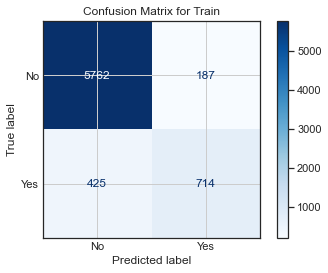

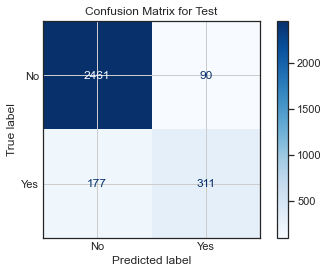

In [149]:
lr_score=get_metrics_score(pipe_lr,"LogisticRegression",X_train,X_test,y_train,y_test)

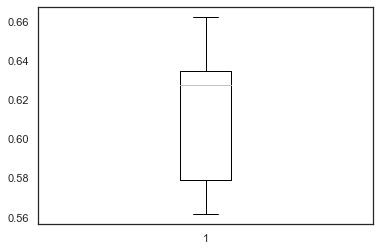

In [150]:
#Evaluate the model performance by using KFold and cross_val_score
scoring="recall"
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)     #Setting number of splits equal to 5
lr_cv_result=cross_val_score(estimator=pipe_lr, X=X_train, y=y_train, scoring=scoring, cv=kfold)

#Boxplots for CV scores of model defined above
plt.boxplot(lr_cv_result)
plt.show()

#### Data is imbalanced. Let"s try fixing that by oversampling

### Oversampling

In [76]:
print(f"Before UpSampling, counts of label attrited customer: {sum(y_train==1)}")
print(f"Before UpSampling, counts of label existing customer: {sum(y_train==0)} \n")

#Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy = 1 ,k_neighbors = 5, random_state=1)   
X_train_over, y_train_over = sm.fit_resample(X_train, y_train.ravel())

print(f"After UpSampling, counts of label attrited customer: {sum(y_train_over==1)}")
print(f"After UpSampling, counts of label existing customer: {sum(y_train_over==0)} \n")

print(f"After UpSampling, the shape of train_X: {X_train_over.shape}")
print(f"After UpSampling, the shape of train_y: {y_train_over.shape} \n")

Before UpSampling, counts of label attrited customer: 1139
Before UpSampling, counts of label existing customer: 5949 

After UpSampling, counts of label attrited customer: 5949
After UpSampling, counts of label existing customer: 5949 

After UpSampling, the shape of train_X: (11898, 46)
After UpSampling, the shape of train_y: (11898,) 



In [77]:
lr_over = LogisticRegression(solver="liblinear")
lr_over.fit(X_train_over, y_train_over)

LogisticRegression(solver='liblinear')

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.939402,0.903916,0.919482,0.625,0.957633,0.736715,0.93817,0.676275


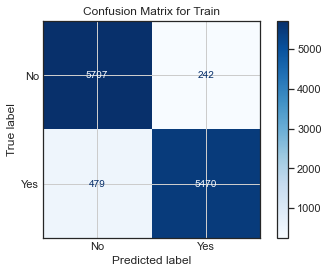

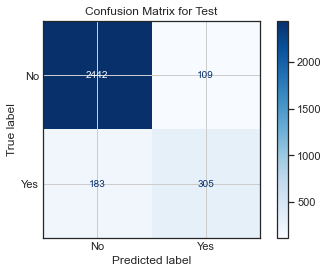

In [81]:
lr_score_over=get_metrics_score(lr_over,"LogisticRegression with over sampling",X_train_over,X_test,y_train_over,y_test)

In [154]:
#Regularization of the oversampled dataset

#Choose the type of classifier. 
pipe_lr_reg = make_pipeline( StandardScaler(), (LogisticRegression(random_state=1)))

#Grid of parameters to choose from
parameters = {"logisticregression__C": np.arange(0.007,0.5,0.01),
              "logisticregression__solver" : ["liblinear","newton-cg","lbfgs","sag","saga"],
              "logisticregression__penalty": ["l1","l2"]
             }

#Run the grid search
grid_obj = RandomizedSearchCV(pipe_lr_reg, parameters, scoring="recall",n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

#Set the clf to the best combination of parameters
pipe_lr_reg = grid_obj.best_estimator_

#Fit the best algorithm to the data. 
pipe_lr_reg.fit(X_train_over, y_train_over)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.017, penalty='l1', random_state=1,
                                    solver='liblinear'))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.94033,0.90622,0.92049,0.63730,0.95852,0.74224,0.93912,0.68578


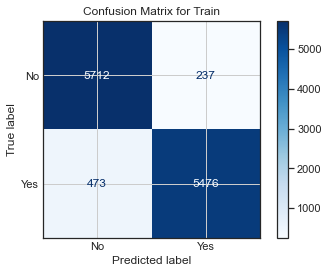

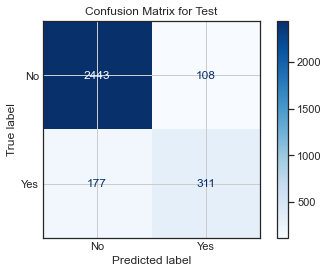

In [155]:
lr_score_under=get_metrics_score(pipe_lr_reg,"LogisticRegression with Regularization on Over sampling",X_train_over,X_test,y_train_over,y_test)

### Undersampling

In [156]:
#Trying undersampling to see if performance improves

#Undersample dependent variable
rus = RandomUnderSampler(random_state = 1)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

#Undersample to balance classes
print("Before Under Sampling, counts of label "Attrited": {}".format(sum(y_train==1)))
print("Before Under Sampling, counts of label "Existing": {} \n".format(sum(y_train==0)))

print("After Under Sampling, counts of label "Attrited": {}".format(sum(y_train_under==1)))
print("After Under Sampling, counts of label "Existing": {} \n".format(sum(y_train_under==0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_under.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_under.shape))
                                          

Before Under Sampling, counts of label 'Attrited': 1139
Before Under Sampling, counts of label 'Existing': 5949 

After Under Sampling, counts of label 'Attrited': 1139
After Under Sampling, counts of label 'Existing': 1139 

After Under Sampling, the shape of train_X: (2278, 46)
After Under Sampling, the shape of train_y: (2278,) 



In [157]:
# Logistic regression on undersampled data

# Initialize model using pipeline
pipe_lr_under = make_pipeline( StandardScaler(), (LogisticRegression(random_state=1)))

# Training the basic logistic regression model with training set 
pipe_lr_under.fit(X_train_under,y_train_under)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression', LogisticRegression(random_state=1))])

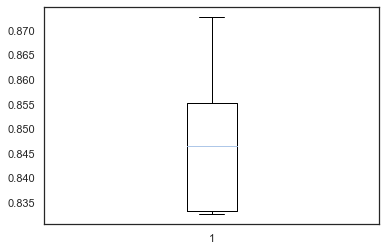

In [158]:
#Evaluate the model performance by using KFold and cross_val_score
scoring="recall"
#Set number of splits to 5
kfold=StratifiedKFold(n_splits=5,shuffle=True,random_state=1)    
cv_result_under=cross_val_score(estimator=pipe_lr_under, X=X_train_under, y=y_train_under, scoring=scoring, cv=kfold)

#Plotting boxplots for CV scores of model defined above
plt.boxplot(cv_result_under)
plt.show()

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.85777,0.84962,0.85777,0.84016,0.85777,0.51965,0.85777,0.64213


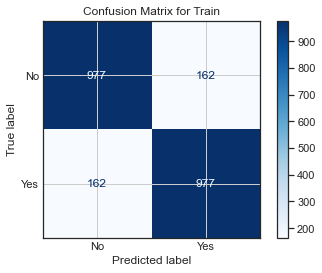

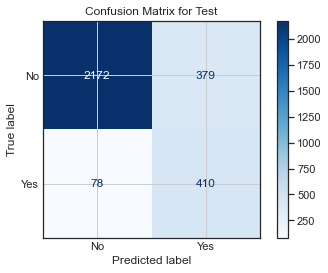

In [159]:
lr_score_under=get_metrics_score(pipe_lr_under,"LogisticRegression with under sampling",X_train_under,X_test,y_train_under,y_test)

#### After undersampling the model improves on both the training and test sets. Recall is better on the test set compared to oversampling. 

In [160]:
#Choose the type of classifier. 
pipe_lr_reg_under = make_pipeline( StandardScaler(), (LogisticRegression(random_state=1)))

#Grid of parameters to choose from
parameters = {"logisticregression__C": np.arange(0.007,0.5,0.01),
              "logisticregression__solver" : ["liblinear","newton-cg","lbfgs","sag","saga"],
              "logisticregression__penalty": ["l1","l2"]
             }

#Run the grid search
grid_obj = RandomizedSearchCV(pipe_lr_reg_under, parameters, scoring="recall",n_jobs=-1)
grid_obj = grid_obj.fit(X_train_under, y_train_under)

#Set the clf to the best combination of parameters
pipe_lr_reg_under = grid_obj.best_estimator_

#Fit the best algorithm to the data. 
pipe_lr_reg_under.fit(X_train_under, y_train_under)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(C=0.4570000000000001, penalty='l1',
                                    random_state=1, solver='liblinear'))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.85470,0.84798,0.85514,0.83811,0.85439,0.51641,0.85476,0.63906


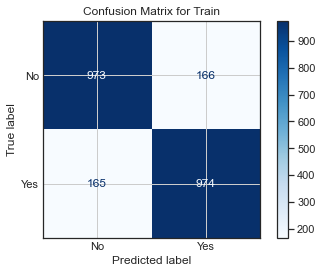

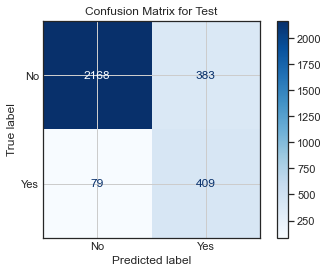

In [161]:
lr_score_reg=get_metrics_score(pipe_lr_reg_under,"LogisticRegression with Regularization on Undersampled",X_train_under,X_test,y_train_under,y_test)

### Improvement

In [162]:
comparison_frame = pd.DataFrame({"Model":model_name,
                                          "Train_Accuracy": acc_train,"Test_Accuracy": acc_test,
                                          "Train_Recall":recall_train,"Test_Recall":recall_test,
                                          "Train_Precision":precision_train,"Test_Precision":precision_test,
                                          "Train_F1":f1_train,
                                          "Test_F1":f1_test  }) 

#Sort models in decreasing order of test recall
comparison_frame.sort_values(by="Test_Recall",ascending=False)

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1,Test_F1
3,LogisticRegression with under sampling,0.85777,0.84962,0.85777,0.84016,0.85777,0.51965,0.85777,0.64213
4,LogisticRegression with Regularization on Undersampled,0.85470,0.84798,0.85514,0.83811,0.85439,0.51641,0.85476,0.63906
0,LogisticRegression,0.91366,0.91214,0.62687,0.63730,0.79245,0.77556,0.70000,0.69966
2,LogisticRegression with Regularization on Over sampling,0.94033,0.90622,0.92049,0.63730,0.95852,0.74224,0.93912,0.68578
1,LogisticRegression with over sampling,0.93940,0.90392,0.91948,0.62500,0.95763,0.73671,0.93817,0.67627


## Decision Tree, Bagging, and Boosting

In [163]:
#Empty list to store all the models
models = [] 

#Appending pipelines for each model into the list
models.append(
    (
        "DTREE",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("decision_tree", DecisionTreeClassifier(random_state=1)),
            ]
        ),
    )
)

models.append(
    (
        "RF",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("random_forest", RandomForestClassifier(random_state=1)),
            ]
        ),
    )
)

models.append(
    (
        "BG",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("bagging", BaggingClassifier(random_state=1)),
            ]
        ),
    )
)
models.append(
    (
        "GBM",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("gradient_boosting", GradientBoostingClassifier(random_state=1)),
            ]
        ),
    )
)
models.append(
    (
        "ADB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("adaboost", AdaBoostClassifier(random_state=1)),
            ]
        ),
    )
)
models.append(
    (
        "XGB",
        Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("xgboost", XGBClassifier(random_state=1,eval_metric="logloss")),
            ]
        ),
    )
)


#Empty list to store all model"s CV scores
results = [] 
#Empty list to store model names
names = []

#Loop through all models to get the mean cross validated score
for name, model in models:
    scoring = "recall"
    kfold = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=1
    ) 
    cv_result = cross_val_score(
        estimator=model, X=X_train, y=y_train, scoring=scoring, cv=kfold
    )
    results.append(cv_result)
    names.append(name)
    print("{}: {}".format(name, cv_result.mean() * 100))

DTREE: 77.78537754076822
RF: 72.78112682587526
BG: 79.54246850606694
GBM: 82.61341680191669
ADB: 80.77053868150553
XGB: 85.77672153953164


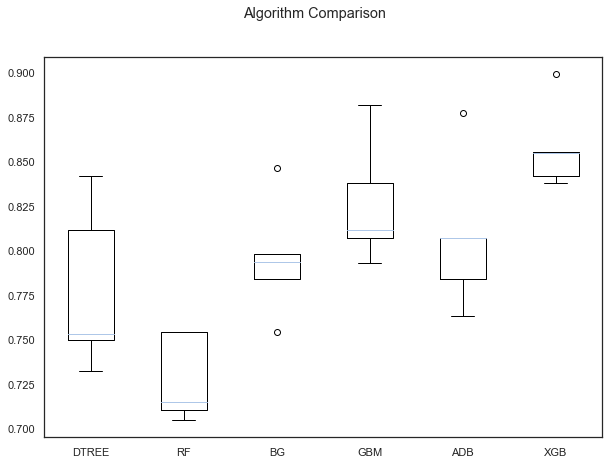

In [164]:
#Plotting boxplots for CV scores of all models
fig = plt.figure(figsize=(10, 7))

fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)

plt.boxplot(results)
ax.set_xticklabels(names)

plt.show()

## Hyperparameter Tuning

### Adaboost with Grid Search

In [166]:
%%time
#Creating pipeline
pipe_ada_grid = make_pipeline(StandardScaler(), AdaBoostClassifier(random_state=1))

#Parameter grid to pass in GridSearchCV
param_grid = {
    "adaboostclassifier__n_estimators": np.arange(10, 110, 10),
    "adaboostclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "adaboostclassifier__base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
#Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling GridSearchCV
pipe_ada_grid = GridSearchCV(estimator=pipe_ada_grid, param_grid=param_grid, scoring=scorer, cv=5,n_jobs = -1)

#Fitting parameters with undersampled train data in GridSeachCV
pipe_ada_grid.fit(X_train, y_train)
                              
print("Best parameters are {} with CV score={}:" .format(pipe_ada_grid.best_params_,pipe_ada_grid.best_score_))

Best parameters are {'adaboostclassifier__base_estimator': DecisionTreeClassifier(max_depth=2, random_state=1), 'adaboostclassifier__learning_rate': 1, 'adaboostclassifier__n_estimators': 100} with CV score=0.8683205811886545:
CPU times: total: 3.92 s
Wall time: 55.7 s


In [101]:
#New pipeline with optimum parameters
abc_tuned_grid = make_pipeline(
    StandardScaler(),AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2, 
                                                                              random_state=1),
                                        learning_rate=1, n_estimators=70))

#Fit the model on undersampled training data
abc_tuned_grid.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('adaboostclassifier',
                 AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                                          random_state=1),
                                    learning_rate=1, n_estimators=70))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.98476,0.96611,0.93766,0.88730,0.96652,0.90021,0.95187,0.89370


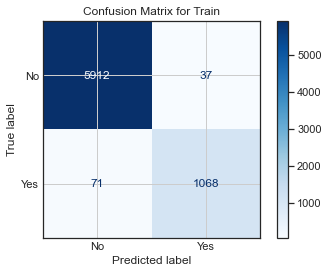

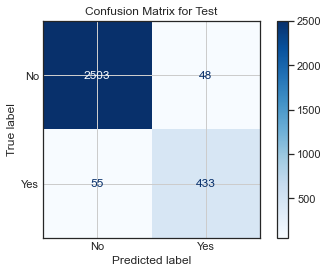

In [168]:
abc_tuned_score=get_metrics_score(abc_tuned_grid," Adaboost with Grid Search",X_train,X_test,y_train,y_test)

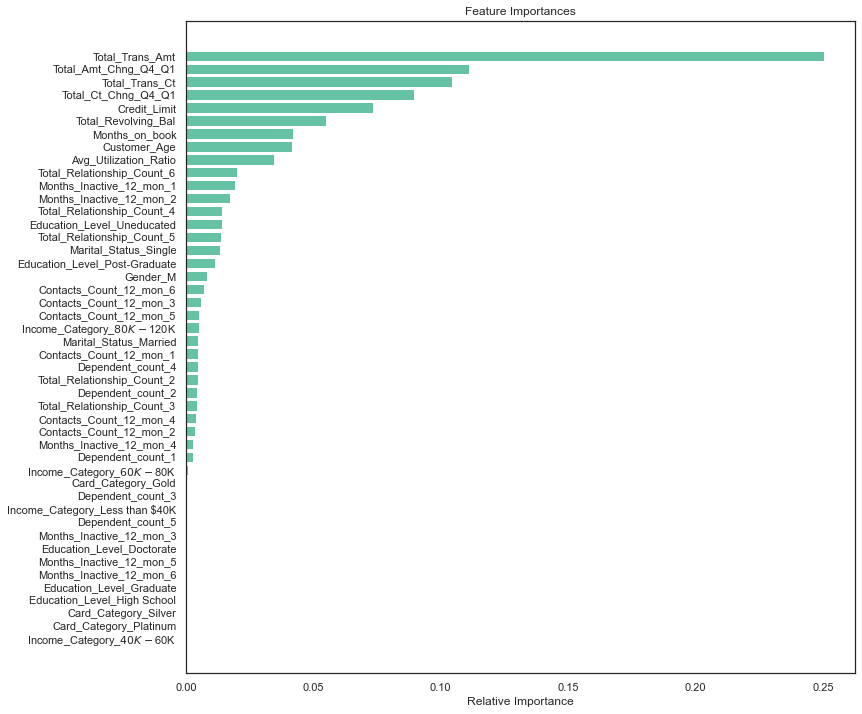

In [102]:
feature_names = X_train.columns
importances = abc_tuned_grid[1].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Test recall increased and model is generalized

### Adaboost with Random Search

In [170]:
%%time

#Creating pipeline
pipe_ada_ran = make_pipeline(StandardScaler(), AdaBoostClassifier(random_state=1))

#Parameter grid to pass in GridSearchCV
param_grid = {
    "adaboostclassifier__n_estimators": np.arange(10, 110, 10),
    "adaboostclassifier__learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "adaboostclassifier__base_estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=1),
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
#Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
abc_rand_cv = RandomizedSearchCV(estimator=pipe_ada_ran, param_distributions=param_grid, n_iter=10,n_jobs = -1, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
abc_rand_cv.fit(X_train,y_train)


print("Best parameters are {} with CV score={}:" .format(abc_rand_cv.best_params_,abc_rand_cv.best_score_))

Best parameters are {'adaboostclassifier__n_estimators': 90, 'adaboostclassifier__learning_rate': 1, 'adaboostclassifier__base_estimator': DecisionTreeClassifier(max_depth=2, random_state=1)} with CV score=0.865677409382487:
CPU times: total: 1.23 s
Wall time: 4.53 s


In [103]:
#New pipeline with optimum parameters
abc_tuned_rand = make_pipeline(
    StandardScaler(),AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                                              random_state=1),
                                        learning_rate=1, n_estimators=90))

#Fit the model on training data
abc_tuned_rand.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('adaboostclassifier',
                 AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                                          random_state=1),
                                    learning_rate=1, n_estimators=90))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,0.99196,0.96479,0.96752,0.88115,0.98217,0.89770,0.97479,0.88935


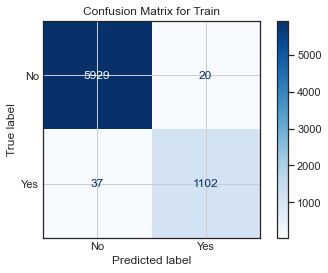

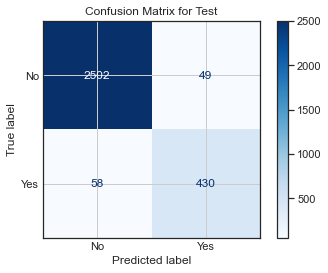

In [172]:
abc_rand_tuned_score=get_metrics_score(abc_tuned_rand," Adaboost with Random Search",X_train,X_test,y_train,y_test)

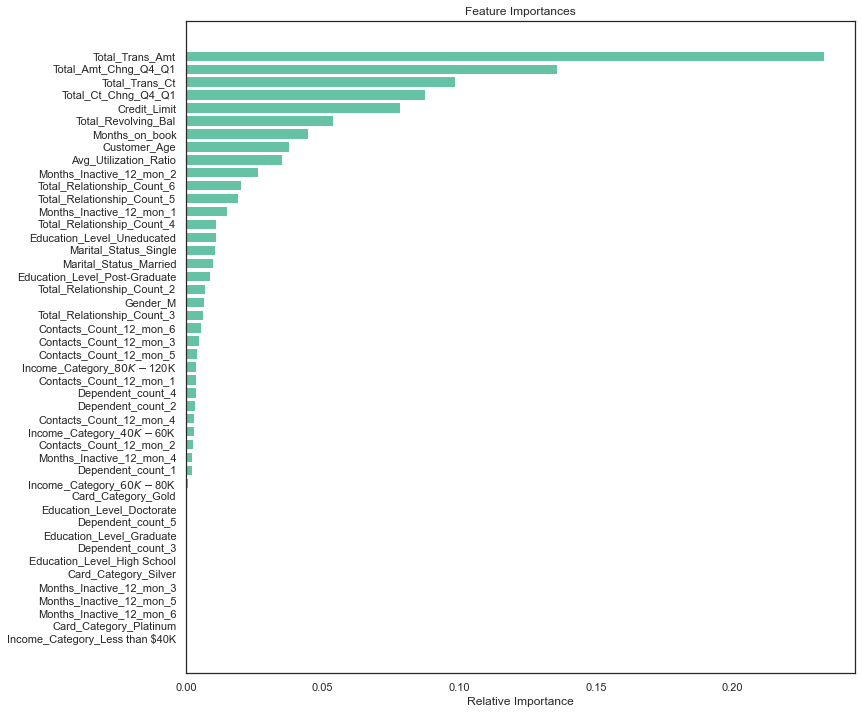

In [104]:
feature_names = X_train.columns
importances = abc_tuned_rand[1].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Recall improved and was signifigantly faster than random search

### Gradient Boosting with Grid Search

In [174]:
%%time
#Creating pipeline
pipe_gb_grid = make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=1))

#Grid of parameters to choose from
param_grid = {"gradientboostingclassifier__n_estimators":[100,200],
              "gradientboostingclassifier__max_depth":[10,20],
              "gradientboostingclassifier__min_samples_leaf": [10,20],
              "gradientboostingclassifier__min_samples_split": [25,35]
              }
#Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

#Run the grid search
grid_cv = GridSearchCV(pipe_gb_grid, param_grid, scoring=scorer,cv=5,n_jobs = -1)

#Fitting parameters in GridSeachCV
pipe_gb_grid = grid_cv.fit(X_train, y_train)


print("Best parameters are {} with CV score={}:" .format(pipe_gb_grid.best_params_,grid_cv.best_score_))

Best parameters are {'gradientboostingclassifier__max_depth': 20, 'gradientboostingclassifier__min_samples_leaf': 20, 'gradientboostingclassifier__min_samples_split': 25, 'gradientboostingclassifier__n_estimators': 200} with CV score=0.8656928665275524:
CPU times: total: 14.9 s
Wall time: 1min 23s


In [105]:
#New pipeline with optimum parameters
gb_tuned_grid = make_pipeline(
    StandardScaler(),GradientBoostingClassifier(max_depth=20,
                                            min_samples_leaf=20,
                                            min_samples_split=25,
                                            n_estimators=200, random_state=1
                                            ))

#Fit the model on training data
gb_tuned_grid.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=20, min_samples_leaf=20,
                                            min_samples_split=25,
                                            n_estimators=200,
                                            random_state=1))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,1.00000,0.97170,1.00000,0.89549,1.00000,0.92585,1.00000,0.91042


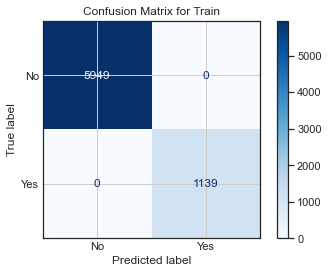

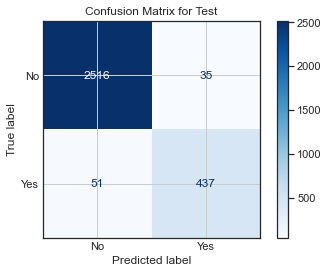

In [176]:
gb_tuned_score=get_metrics_score(gb_tuned_grid," Gradient with Grid Search",X_train,X_test,y_train,y_test)

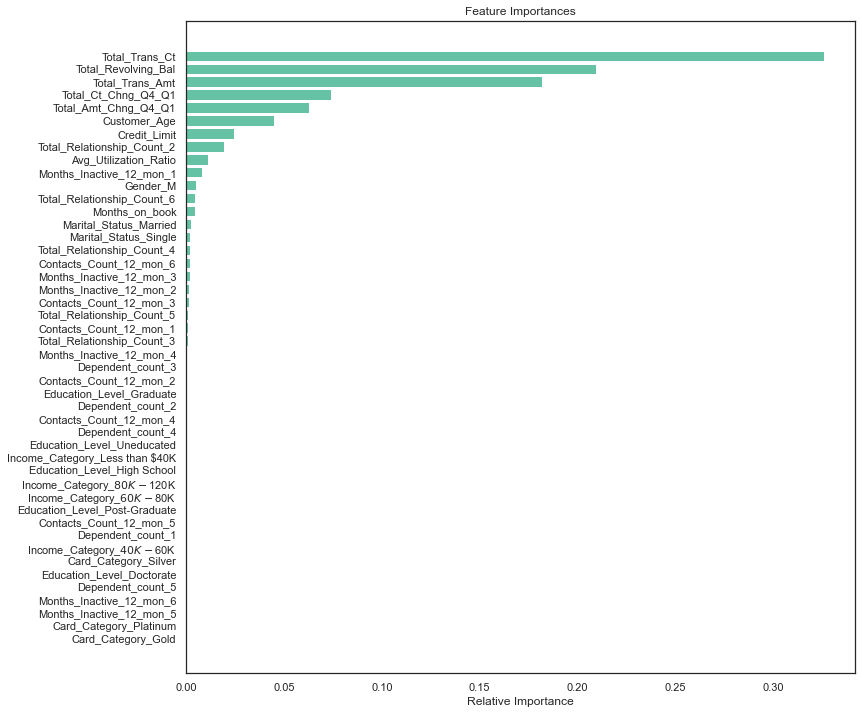

In [106]:
feature_names = X_train.columns
importances = gb_tuned_grid[1].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Model is overfitting, but grid search still gave a better recall score than cross validation

### Gradient Boosting with Grid Search

In [178]:
%%time 
pipe_gb_rand = make_pipeline(StandardScaler(), GradientBoostingClassifier(random_state=1))

param_grid = {"gradientboostingclassifier__n_estimators":[100,200],
              "gradientboostingclassifier__max_depth":[10,20],
              "gradientboostingclassifier__min_samples_leaf": [10,20],
              "gradientboostingclassifier__min_samples_split": [25,35]
              }


scorer = metrics.make_scorer(metrics.recall_score)

#Calling RandomizedSearchCV
pipe_gb_rand = RandomizedSearchCV(estimator=pipe_gb_rand, param_distributions=param_grid,n_jobs = -1, n_iter=10, scoring=scorer, cv=5, random_state=1)

#Fitting parameters in RandomizedSearchCV
pipe_gb_rand.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(pipe_gb_rand.best_params_,pipe_gb_rand.best_score_))

Best parameters are {'gradientboostingclassifier__n_estimators': 200, 'gradientboostingclassifier__min_samples_split': 25, 'gradientboostingclassifier__min_samples_leaf': 20, 'gradientboostingclassifier__max_depth': 20} with CV score=0.8656928665275524:
CPU times: total: 14.8 s
Wall time: 49.9 s


In [107]:
gb_tuned_rand = make_pipeline(
    StandardScaler(),GradientBoostingClassifier(max_depth=20, min_samples_leaf=20,
                                            min_samples_split=25,
                                            n_estimators=200,
                                            random_state=1))

#Fit the model on training data
gb_tuned_rand.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gradientboostingclassifier',
                 GradientBoostingClassifier(max_depth=20, min_samples_leaf=20,
                                            min_samples_split=25,
                                            n_estimators=200,
                                            random_state=1))])

Metric,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1-Score,Test_F1-Score
Score,1.00000,0.97170,1.00000,0.89549,1.00000,0.92585,1.00000,0.91042


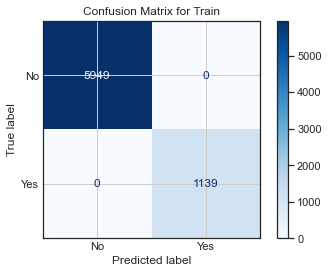

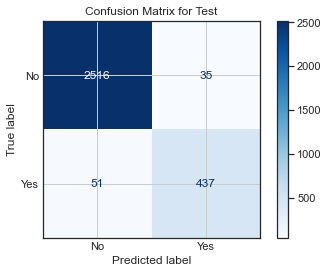

In [180]:
gb_rand_tuned_score=get_metrics_score(gb_tuned_rand," Gradient boosting with Random Search",X_train,X_test,y_train,y_test)

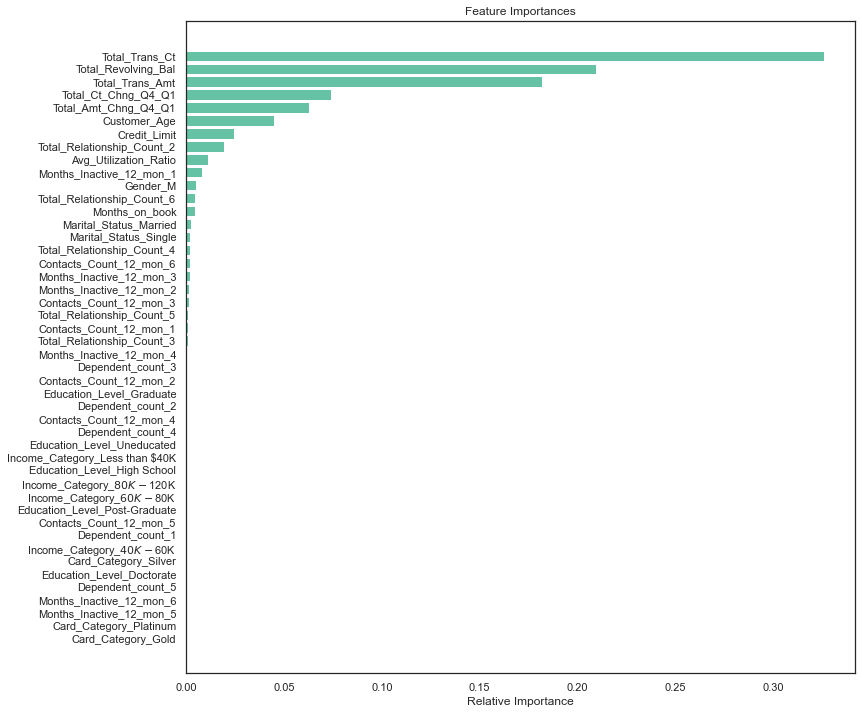

In [108]:
feature_names = X_train.columns
importances = gb_tuned_rand[1].feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

#### Also overperforms, and was much slower than random search

### Comparing All Models

In [182]:
comparison_frame = pd.DataFrame({"Model":model_name,
                                          "Train_Accuracy": acc_train,"Test_Accuracy": acc_test,
                                          "Train_Recall":recall_train,"Test_Recall":recall_test,
                                          "Train_Precision":precision_train,"Test_Precision":precision_test,
                                          "Train_F1":f1_train,
                                          "Test_F1":f1_test  }) 

#Sorting models in decreasing order of test recall
comparison_frame.sort_values(by="Test_Recall",ascending=False)

,Model,Train_Accuracy,Test_Accuracy,Train_Recall,Test_Recall,Train_Precision,Test_Precision,Train_F1,Test_F1
7,Gradient with Grid Search,1.00000,0.97170,1.00000,0.89549,1.00000,0.92585,1.00000,0.91042
8,Gradient boosting with Random Search,1.00000,0.97170,1.00000,0.89549,1.00000,0.92585,1.00000,0.91042
5,Adaboost with Grid Search,0.98476,0.96611,0.93766,0.88730,0.96652,0.90021,0.95187,0.89370
6,Adaboost with Random Search,0.99196,0.96479,0.96752,0.88115,0.98217,0.89770,0.97479,0.88935
3,LogisticRegression with under sampling,0.85777,0.84962,0.85777,0.84016,0.85777,0.51965,0.85777,0.64213
4,LogisticRegression with Regularization on Undersampled,0.85470,0.84798,0.85514,0.83811,0.85439,0.51641,0.85476,0.63906
0,LogisticRegression,0.91366,0.91214,0.62687,0.63730,0.79245,0.77556,0.70000,0.69966
2,LogisticRegression with Regularization on Over sampling,0.94033,0.90622,0.92049,0.63730,0.95852,0.74224,0.93912,0.68578
1,LogisticRegression with over sampling,0.93940,0.90392,0.91948,0.62500,0.95763,0.73671,0.93817,0.67627


### Conclusion

#### Random grid seach takes the least amount of time but that doesn"t mean it will have the best performance
#### Total transaction count is the most important feature. Total revolving balance and Total transactional amount are second and third
#### It appears that customers with lower values in these features are more likely to attrite

# Insights

#### Lower transcation counts, less revolving balance, and less transcational amounts are indications that a customer will attrite. Lower transcations mean the customer is not using this card , so the bank should offer rewards or cashback to the customer to start using the card again.
#### Customers who have been inactive for a month have high chances of attrition. The bank should provide an incentive for these customers to start using the card again.
#### The average customer who attrites is 36-55 and a postgrad or doctorate. This might be because a competing bank is offering better deals leading to lesser user of this banks credit card. The bank should try to appeal to this demographic by offering rewards for using the card at locations middle age educated people frequent.
#### Customers who have been contacted several times by the bank in the last 12 months have attrited. Why is that? Poor customer service or lack of efficiency in resolving issues might be a deterrence to customers
#### Customers that hold more products with the bank are less likely to attrite. The bank should offer more products to customers so they buy more products which will help retain them.